#Modeling 3

In [ ]:
!pip install boruta
import boruta
from boruta import BorutaPy
import importlib.metadata
print(importlib.metadata.version('boruta'))

0.4.3


In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TOKEN_tabpfn_client="xxx"

In [ ]:
#Definindo semente

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
print(boruta.__version__)

In [ ]:
!pip install tabpfn-client

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.6/220.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 25.4 MB/s eta 0:00:00
  Attempting uninstall: xxhash
    Found existing installation: xxhash 4.0.1
    Uninstalling xxhash-4.0.1:
      Successfully uninstalled xxhash-4.0.1
  Attempting uninstall: requests
    Found existing instal

In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37368 sha256=1adf6befb7ddfac1f23b4f99be7c1d4623fdf891b179c309ae1976e2b243e53a
  Stored in directory: /root/.cache/pip/wheels/ec/b5/10/93c91bf324e855f115998634a7f6091b62d7a6a32d6e62c05b
Successfully built pycalib


In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados3_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados3_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
X_train.head()

,pop,cs_sexo_0.0,cs_sexo_1.0,cs_sexo_9.0,cs_raca_1.0,cs_raca_2.0,cs_raca_3.0,cs_raca_4.0,cs_raca_5.0,cs_raca_9.0,...,escola_faixa_10.0,contato_5_15_0.0,contato_5_15_1.0,contato_5_15_2.0,contato_5_15_9.0,faixa_etaria_0.0,faixa_etaria_1.0,faixa_etaria_2.0,faixa_etaria_3.0,faixa_etaria_9.0
0,0.726841,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.726841,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.726841,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.726841,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.726841,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X.train.columns

##• Proporção do desfecho (Obrigatório)

In [ ]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.878089
0,0.121911


In [ ]:
#Visualização da proporção do desfecho na base de teste
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.89186
0,0.10814


#3- Criação e Avaliação dos Modelos Iniciais

---



##Criação e Tuning dos Modelos

###Random Forest

####Hyperopt

In [ ]:
!pip install hyperopt

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}

# Função objetivo
def objective(params):
    model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    # Acurácia via cross validation (ROC AUC)
    score = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=5, n_jobs=-1).mean()

    # Hyperopt minimiza → então retornamos o negativo
    return {'loss': -score, 'status': STATUS_OK}

# Armazena resultados
trials = Trials()

# Execução da busca
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,   # Número de iterações (equivale ao n_iter)
    trials=trials,
    rstate=np.random.default_rng(seed)
)

print("\nMelhores hiperparâmetros encontrados:")
print(best)

# Reconstruindo o modelo final com os melhores parâmetros
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': int(best['max_depth']),
    'min_samples_split': best['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best['max_features']],
    'random_state': seed
}

rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

print("\nModelo final treinado com Hyperopt.")

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", best_params_hyperopt)


100%|██████████| 50/50 [11:42<00:00, 14.06s/trial, best loss: -0.756014769873733]

Melhores hiperparâmetros encontrados:
{'max_depth': np.float64(14.0), 'max_features': np.int64(1), 'min_samples_leaf': np.int64(1), 'min_samples_split': np.float64(0.010269757116109226), 'n_estimators': np.int64(1)}

Modelo final treinado com Hyperopt.
Hiperparametros do rf  {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': np.float64(0.010269757116109226), 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42}


In [ ]:
rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

RandomForestClassifier(max_depth=14, min_samples_leaf=10,
                       min_samples_split=np.float64(0.010269757116109226),
                       n_estimators=300, random_state=42)

In [ ]:
# Generate predictions and probabilities
y_pred_rf_hyperopt = rf_hyperopt.predict(X_test)
y_prob_rf_hyperopt = rf_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)

# Impressão
print(f'rf - ROC AUC: {auc_rf_hyperopt:.4f}')

rf - ROC AUC: 0.7538


In [ ]:
# Depois do Hyperopt
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)
auc_cv_rf_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
params_rf_hyperopt = best_params_hyperopt

In [ ]:
for params, value in best_params_hyperopt.items():
  print(f"{params}: {value}")

n_estimators: 300
max_depth: 14
min_samples_split: 0.010269757116109226
min_samples_leaf: 10
max_features: sqrt
random_state: 42


####Random Search

In [ ]:
# Modelo e dicionário de busca
rf=RandomForestClassifier(random_state=seed)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# Criação do random search
rf_rs=RandomizedSearchCV(estimator=rf,
                         param_distributions=rf_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", rf_rs.best_params_)

# Criação do modelo final
rf=rf_rs.best_estimator_


Hiperparametros do rf  {'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_rs = rf.predict(X_test)
y_prob_rf_rs = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
auc_cv_rf_rs = rf_rs.best_score_

# Impressão
print(f'rf - ROC AUC: {auc_rf_rs:.4f}')

rf - ROC AUC: 0.7550


In [ ]:
# Depois do Random Search
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
params_rf_rs = rf_rs.best_params_

In [ ]:
for params, value in rf_rs.best_params_.items():
    print(f"{params}: {value}")


n_estimators: 300
min_samples_split: 0.01
min_samples_leaf: 10
max_features: log2
max_depth: 10


####Optuna

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 10.6 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc
# ===============================
# IMPORTS
# ===============================
import numpy as np
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ===============================
# OPTUNA - FUNÇÃO OBJETIVO
# ===============================
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# TREINO DO MODELO FINAL
# ===============================
rf = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]




[I 2026-09-08 14:59:59,156] A new study created in memory with name: no-name-baf5b8a4-fa57-41fd-a842-2e0ee43863c9
[I 2026-09-08 15:00:38,847] Trial 0 finished with value: 0.7493959723048939 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 0.026802151038888354, 'min_samples_leaf': 16, 'max_features': None}. Best is trial 0 with value: 0.7493959723048939.
[I 2026-09-08 15:01:42,762] Trial 1 finished with value: 0.7479463502253129 and parameters: {'n_estimators': 500, 'max_depth': 9, 'min_samples_split': 0.037699543936288875, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 0 with value: 0.7493959723048939.
[I 2026-09-08 15:01:51,768] Trial 2 finished with value: 0.7519756306777656 and parameters: {'n_estimators': 400, 'max_depth': 12, 'min_samples_split': 0.03503709332957436, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial 2 with value: 0.7519756306777656.
[I 2026-09-08 15:02:46,056] Trial 3 finished with value: 0.7488418590367325 and p


Melhor AUC (CV): 0.7579194005576836
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 0.010595012930412106, 'min_samples_leaf': 12, 'max_features': 'sqrt'}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_optuna = rf.predict(X_test)
y_prob_rf_optuna = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
auc_cv_rf_optuna = study.best_value

# Impressão
print(f'rf - ROC AUC: {auc_rf_optuna:.4f}')

rf - ROC AUC: 0.7536


In [ ]:
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
params_rf_optuna = study.best_params

In [ ]:
for params, value in study.best_params.items():
    print(f"{params}: {value}")


n_estimators: 400
max_depth: 14
min_samples_split: 0.010595012930412106
min_samples_leaf: 12
max_features: sqrt


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd



# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [auc_cv_rf_rs],
    'Hyperopt': [auc_cv_rf_hyperopt],
    'Optuna': [auc_cv_rf_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [params_rf_rs],
    'Hyperopt': [params_rf_hyperopt],
    'Optuna': [params_rf_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_rf)


===== Tabela AUC-ROC =====
         Modelo  RandomSearch  Hyperopt    Optuna
0  RandomForest      0.754725  0.756015  0.757919


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf = df_auc_rf.drop(columns='Modelo').max(axis=1)[0]
best_model_rf = df_auc_rf['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf} ({best_method_rf}) = {best_auc_rf:.4f}")

✅ Modelo com maior AUC-ROC: RandomForest (Optuna) = 0.7579


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf == 'RandomSearch':
    best_params_rf_final = params_rf_rs
elif best_method_rf == 'Hyperopt':
    best_params_rf_final = params_rf_hyperopt
elif best_method_rf == 'Optuna':
    best_params_rf_final = params_rf_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 0.010595012930412106, 'min_samples_leaf': 12, 'max_features': 'sqrt'}


In [ ]:
print("params_rf_rs:")
print(params_rf_rs)
print(type(params_rf_rs))

print("\nparams_rf_hyperopt:")
print(params_rf_hyperopt)
print(type(params_rf_hyperopt))

print("\nparams_rf_optuna:")
print(params_rf_optuna)
print(type(params_rf_optuna))

params_rf_rs:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
<class 'dict'>

params_rf_hyperopt:
{'n_estimators': 300, 'max_depth': 14, 'min_samples_split': np.float64(0.010269757116109226), 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42}
<class 'dict'>

params_rf_optuna:
{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 0.010595012930412106, 'min_samples_leaf': 12, 'max_features': 'sqrt'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_final = RandomForestClassifier(
    **{**best_params_rf_final, **({"random_state": seed} if "random_state" not in best_params_rf_final else {})}
)

# Treinar usando seus dados completos de treino
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=14, min_samples_leaf=12,
                       min_samples_split=0.010595012930412106, n_estimators=400,
                       random_state=42)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf.pkl"

joblib.dump(rf_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf.pkl


In [ ]:
joblib.dump({
    "model_rf": rf_final,
    "params_rf": best_params_rf_final,
    "method_rf": best_method_rf,
    "auc_cv_rf": best_auc_rf
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf.pkl']

In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])
print(data["auc_cv_rf"])

{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 0.010595012930412106, 'min_samples_leaf': 12, 'max_features': 'sqrt'}
Optuna
0.7579194005576836


###LGBM

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb = LGBMClassifier(
    **best_params_hyperopt,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_hyperopt:.4f}")

100%|██████████| 50/50 [05:33<00:00,  6.67s/trial, best loss: -0.7609560249896994]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 12, 'min_data_in_leaf': 17, 'learning_rate': np.float64(0.02222324714828151), 'subsample': np.float64(0.998911211560766), 'colsample_bytree': np.float64(0.7398826898177897), 'reg_alpha': np.float64(0.9898777015790734), 'reg_lambda': np.float64(1.291747341273912)}
[LightGBM] [Warning] min_data_in_leaf is set=17, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=17
[LightGBM] [Warning] min_data_in_leaf is set=17, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=17
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 176
[LightG

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_hyperopt = lgb.predict(X_test)
y_prob_lgb_hyperopt = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
auc_cv_lgb_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=17, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=17
[LightGBM] [Warning] min_data_in_leaf is set=17, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=17
lgb - ROC AUC: 0.7607


In [ ]:
# Depois do Hyperopt
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
params_lgb_hyperopt = best_params_hyperopt

In [ ]:
for param, value in best_params_hyperopt.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 12
min_data_in_leaf: 17
learning_rate: 0.02222324714828151
subsample: 0.998911211560766
colsample_bytree: 0.7398826898177897
reg_alpha: 0.9898777015790734
reg_lambda: 1.291747341273912


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb))


[I 2026-09-08 15:15:57,664] A new study created in memory with name: no-name-54917325-4fb6-4ef3-be69-ed6641d373eb
[I 2026-09-08 15:16:15,560] Trial 0 finished with value: 0.7579429274041283 and parameters: {'n_estimators': 300, 'max_depth': 12, 'min_data_in_leaf': 17, 'learning_rate': 0.03882062423480231, 'subsample': 0.6041452144410017, 'colsample_bytree': 0.7437712403908009, 'reg_alpha': 0.05728282300092139, 'reg_lambda': 1.7131242514565512}. Best is trial 0 with value: 0.7579429274041283.
[I 2026-09-08 15:16:33,168] Trial 1 finished with value: 0.7291622072771167 and parameters: {'n_estimators': 500, 'max_depth': 9, 'min_data_in_leaf': 15, 'learning_rate': 0.11848726103643517, 'subsample': 0.8603039169299131, 'colsample_bytree': 0.6733530109331426, 'reg_alpha': 0.02190346940359625, 'reg_lambda': 1.4769530224174525}. Best is trial 0 with value: 0.7579429274041283.
[I 2026-09-08 15:16:55,358] Trial 2 finished with value: 0.7602774255020034 and parameters: {'n_estimators': 500, 'max_de


Melhor AUC (CV): 0.7632301134777979
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_lambda': 1.2194830985998353}
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 69
[LightGBM] [Info] [binary:BoostFr

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_optuna = lgb.predict(X_test)
y_prob_lgb_optuna = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
lgb - ROC AUC: 0.7589


In [ ]:
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)
auc_cv_lgb_optuna = study.best_value
params_lgb_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 500
max_depth: 14
min_data_in_leaf: 7
learning_rate: 0.011535949965568348
subsample: 0.6039174462793708
colsample_bytree: 0.6385457872559661
reg_alpha: 0.07233954232631701
reg_lambda: 1.2194830985998353


####Random Search

In [ ]:
# Modelo e dicionário de busca
lgb=LGBMClassifier(random_state=seed)
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# Criação do random search
lgb_rs=RandomizedSearchCV(estimator=lgb,
                         param_distributions=lgb_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
lgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do lgb ", lgb_rs.best_params_)

# Criação do modelo final
lgb=lgb_rs.best_estimator_

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456
Hiperparametros do lgb  {'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(0.1), 'n_estimators': np.int64(500), 'min_data_in_leaf': 26, 'max_depth': np.int64(10), 'lea

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
lgb - ROC AUC: 0.7596


In [ ]:
# Depois
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
auc_cv_lgb_rs = lgb_rs.best_score_
params_lgb_rs = lgb_rs.best_params_

In [ ]:
for params, value in lgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 0.6
reg_lambda: 1.5
reg_alpha: 0.1
n_estimators: 500
min_data_in_leaf: 26
max_depth: 10
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [auc_cv_lgb_rs],
    'Hyperopt': [auc_cv_lgb_hyperopt],
    'Optuna': [auc_cv_lgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [params_lgb_rs],
    'Hyperopt': [params_lgb_hyperopt],
    'Optuna': [params_lgb_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_lgb)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt   Optuna
0    lgb      0.761336  0.760956  0.76323


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb = df_auc_lgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb = df_auc_lgb.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb = df_auc_lgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb} ({best_method_lgb}) = {best_auc_lgb:.4f}")

✅ Modelo com maior AUC-ROC: lgb (Optuna) = 0.7632


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb == 'RandomSearch':
    best_params_lgb_final = params_lgb_rs
elif best_method_lgb == 'Hyperopt':
    best_params_lgb_final = params_lgb_hyperopt
elif best_method_lgb == 'Optuna':
    best_params_lgb_final = params_lgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_lambda': 1.2194830985998353}


In [ ]:
print("params_lgb_rs:")
print(params_lgb_rs)
print(type(params_lgb_rs))

print("\nparams_lgb_hyperopt:")
print(params_lgb_hyperopt)
print(type(params_lgb_hyperopt))

print("\nparams_lgb_optuna:")
print(params_lgb_optuna)
print(type(params_lgb_optuna))

params_lgb_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(0.1), 'n_estimators': np.int64(500), 'min_data_in_leaf': 26, 'max_depth': np.int64(10), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_hyperopt:
{'n_estimators': 200, 'max_depth': 12, 'min_data_in_leaf': 17, 'learning_rate': np.float64(0.02222324714828151), 'subsample': np.float64(0.998911211560766), 'colsample_bytree': np.float64(0.7398826898177897), 'reg_alpha': np.float64(0.9898777015790734), 'reg_lambda': np.float64(1.291747341273912)}
<class 'dict'>

params_lgb_optuna:
{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_lambda': 1.2194830985998353}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_final = LGBMClassifier(
    **{**best_params_lgb_final, **({"random_state": seed} if "random_state" not in best_params_lgb_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_final.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456


LGBMClassifier(colsample_bytree=0.6385457872559661,
               learning_rate=0.011535949965568348, max_depth=14,
               min_data_in_leaf=7, n_estimators=500, random_state=42,
               reg_alpha=0.07233954232631701, reg_lambda=1.2194830985998353,
               subsample=0.6039174462793708)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb.pkl"

joblib.dump(lgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb.pkl


In [ ]:
joblib.dump({
    "model_lgb": lgb_final,
    "params_lgb": best_params_lgb_final,
    "method_lgb": best_method_lgb,
    "auc_cv_lgb": best_auc_lgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb.pkl']

In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])
print(data["auc_cv_lgb"])

{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_lambda': 1.2194830985998353}
Optuna
0.7632301134777979


###CatBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
cat = CatBoostClassifier(random_state=seed)
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2

}

# Criação do random search
cat_rs=RandomizedSearchCV(estimator=cat,
                         param_distributions=cat_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
cat_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do cat ", cat_rs.best_params_)

# Criação do modelo final
cat=cat_rs.best_estimator_
auc_cv_cat_rs = cat_rs.best_score_

0:	learn: 0.6710177	total: 51ms	remaining: 20.3s
1:	learn: 0.6488918	total: 54.6ms	remaining: 10.9s
2:	learn: 0.6271101	total: 58.1ms	remaining: 7.69s
3:	learn: 0.6064164	total: 61.5ms	remaining: 6.09s
4:	learn: 0.5867319	total: 65ms	remaining: 5.13s
5:	learn: 0.5694295	total: 68.4ms	remaining: 4.49s
6:	learn: 0.5541083	total: 71.9ms	remaining: 4.04s
7:	learn: 0.5396266	total: 75.5ms	remaining: 3.7s
8:	learn: 0.5250987	total: 78.9ms	remaining: 3.43s
9:	learn: 0.5121795	total: 82.3ms	remaining: 3.21s
10:	learn: 0.4998842	total: 85.2ms	remaining: 3.01s
11:	learn: 0.4889876	total: 88.7ms	remaining: 2.87s
12:	learn: 0.4785062	total: 92.2ms	remaining: 2.74s
13:	learn: 0.4691641	total: 95.7ms	remaining: 2.64s
14:	learn: 0.4595761	total: 99.2ms	remaining: 2.54s
15:	learn: 0.4511634	total: 103ms	remaining: 2.46s
16:	learn: 0.4433886	total: 106ms	remaining: 2.39s
17:	learn: 0.4359395	total: 110ms	remaining: 2.33s
18:	learn: 0.4292281	total: 113ms	remaining: 2.27s
19:	learn: 0.4228442	total: 117

In [ ]:
# Generate predictions and probabilities
y_pred_cat_rs = cat.predict(X_test)
y_prob_cat_rs = cat.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)

# Impressão
print(f'cat - ROC AUC: {auc_cat_rs:.4f}')

cat - ROC AUC: 0.7639


In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)
params_cat_rs = cat_rs.best_params_

In [ ]:
for param, value in cat_rs.best_params_.items():
    print(f"{param}: {value}")

subsample: 0.6
reg_lambda: 1.5
n_estimators: 400
min_data_in_leaf: 10
max_depth: 5


####Hyperopt

In [ ]:
!pip install hyperopt catboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt equivalente ao cat_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = CatBoostClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_data_in_leaf=params['min_data_in_leaf'],
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Armazena histórico da otimização
trials = Trials()

# Execução da busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,   # TPE = otimização bayesiana
    max_evals=50,       # equivalente ao n_iter do RandomSearchCV
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos parâmetros (hp.choice retorna índice)
cat_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best['min_data_in_leaf']],
    'subsample': best['subsample'],
    'reg_lambda': best['reg_lambda'],
    'random_state': seed
}

auc_cv_cat_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

print("\nMelhores hiperparâmetros encontrados:")
print(cat_hyperopt_best_params)

# Modelo final
cat_hyperopt = CatBoostClassifier(**cat_hyperopt_best_params, verbose=0)
cat_hyperopt.fit(X_train, y_train)

print("\nModelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.")

100%|██████████| 50/50 [14:06<00:00, 16.92s/trial, best loss: -0.7633680466230726]

Melhores hiperparâmetros encontrados:
{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8431180872045121), 'reg_lambda': np.float64(1.2956703388603508), 'random_state': 42}

Modelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.


In [ ]:
# Generate predictions and probabilities
y_pred_cat_hyperopt = cat_hyperopt.predict(X_test)
y_prob_cat_hyperopt = cat_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)

# Impressão
print(f'cat - ROC AUC: {auc_cat_hyperopt:.4f}')

cat - ROC AUC: 0.7651


In [ ]:
# Depois do Hyperopt
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)
params_cat_hyperopt = cat_hyperopt_best_params

In [ ]:
for param, value in cat_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 500
max_depth: 3
min_data_in_leaf: 26
subsample: 0.8431180872045121
reg_lambda: 1.2956703388603508
random_state: 42


####Optuna

In [ ]:
!pip install optuna
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_cat(trial):

    cat = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        cat,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
cat = optuna.create_study(direction="maximize")
cat.optimize(objective_cat, n_trials=50)


[I 2026-09-08 15:47:04,652] A new study created in memory with name: no-name-cbae75ce-1e6f-45de-aa0b-cb767c458133
[I 2026-09-08 15:47:20,482] Trial 0 finished with value: 0.7603368446335153 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_data_in_leaf': 5, 'subsample': 0.7324832475104898, 'reg_lambda': 1.051296690717939}. Best is trial 0 with value: 0.7603368446335153.
[I 2026-09-08 15:47:31,707] Trial 1 finished with value: 0.7614804982265653 and parameters: {'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 26, 'subsample': 0.714076533590495, 'reg_lambda': 1.5074561062701974}. Best is trial 1 with value: 0.7614804982265653.
[I 2026-09-08 15:47:40,004] Trial 2 finished with value: 0.7610161892940225 and parameters: {'n_estimators': 300, 'max_depth': 3, 'min_data_in_leaf': 5, 'subsample': 0.8686177393863194, 'reg_lambda': 1.2364154535302405}. Best is trial 1 with value: 0.7614804982265653.
[I 2026-09-08 15:47:46,689] Trial 3 finished with value: 0.7608733840698017 and 

In [ ]:
auc_cv_cat_optuna=study.best_value
print("Melhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros (CatBoost):")
print(cat.best_params)


Melhor AUC (CV): 0.7632301134777979
Melhores hiperparâmetros (CatBoost):
{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9177270416658061, 'reg_lambda': 1.97707200752729}


In [ ]:
cat_optuna = CatBoostClassifier(
    **cat.best_params,
    random_state=seed,
    verbose=0
)

cat_optuna.fit(X_train, y_train)


CatBoostClassifier(max_depth=4, min_data_in_leaf=10, n_estimators=500, random_state=42, reg_lambda=1.97707200752729, subsample=0.9177270416658061, verbose=0)

In [ ]:
# Generate predictions and probabilities
y_pred_cat_optuna = cat_optuna.predict(X_test)
y_prob_cat_optuna = cat_optuna.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)

# Impressão
print(f'cat - ROC AUC: {auc_cat_optuna:.4f}')

cat - ROC AUC: 0.7651


In [ ]:
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)
params_cat_optuna = cat.best_params

In [ ]:
for param, value in cat.best_params.items():
    print(f"{param}: {value}")

n_estimators: 500
max_depth: 4
min_data_in_leaf: 10
subsample: 0.9177270416658061
reg_lambda: 1.97707200752729


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd


# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [auc_cv_cat_rs],
    'Hyperopt': [auc_cv_cat_hyperopt],
    'Optuna': [auc_cv_cat_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [params_cat_rs],
    'Hyperopt': [params_cat_hyperopt],
    'Optuna': [params_cat_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cat)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt   Optuna
0    cat      0.762951  0.763368  0.76323


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat = df_auc_cat.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat = df_auc_cat.drop(columns='Modelo').max(axis=1)[0]
best_model_cat = df_auc_cat['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat} ({best_method_cat}) = {best_auc_cat:.4f}")

✅ Modelo com maior AUC-ROC: cat (Hyperopt) = 0.7634


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat == 'RandomSearch':
    best_params_cat_final = params_cat_rs
elif best_method_cat == 'Hyperopt':
    best_params_cat_final = params_cat_hyperopt
elif best_method_cat == 'Optuna':
    best_params_cat_final = params_cat_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_final)



✅ Melhor método: Hyperopt
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8431180872045121), 'reg_lambda': np.float64(1.2956703388603508), 'random_state': 42}


In [ ]:
print("params_cat_rs:")
print(params_cat_rs)
print(type(params_cat_rs))

print("\nparams_cat_hyperopt:")
print(params_cat_hyperopt)
print(type(params_cat_hyperopt))

print("\nparams_cat_optuna:")
print(params_cat_optuna)
print(type(params_cat_optuna))

params_cat_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.5), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(5)}
<class 'dict'>

params_cat_hyperopt:
{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8431180872045121), 'reg_lambda': np.float64(1.2956703388603508), 'random_state': 42}
<class 'dict'>

params_cat_optuna:
{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9177270416658061, 'reg_lambda': 1.97707200752729}
<class 'dict'>


In [ ]:
from catboost import CatBoostClassifier  #

# Criar modelo com os melhores parâmetros
cat_final = CatBoostClassifier(
    **{**best_params_cat_final, **({"random_state": seed} if "random_state" not in best_params_cat_final else {})}
)

# Treinar usando seus dados completos de treino
cat_final.fit(X_train, y_train)

0:	learn: 0.6711876	total: 3.18ms	remaining: 1.59s
1:	learn: 0.6492061	total: 6.02ms	remaining: 1.5s
2:	learn: 0.6283430	total: 8.84ms	remaining: 1.47s
3:	learn: 0.6104087	total: 11.7ms	remaining: 1.46s
4:	learn: 0.5918970	total: 14.7ms	remaining: 1.46s
5:	learn: 0.5752474	total: 17.6ms	remaining: 1.45s
6:	learn: 0.5603389	total: 20.5ms	remaining: 1.44s
7:	learn: 0.5451101	total: 23.3ms	remaining: 1.43s
8:	learn: 0.5309369	total: 26.1ms	remaining: 1.42s
9:	learn: 0.5175189	total: 28.9ms	remaining: 1.41s
10:	learn: 0.5050121	total: 31.5ms	remaining: 1.4s
11:	learn: 0.4944525	total: 34.1ms	remaining: 1.39s
12:	learn: 0.4841001	total: 40.9ms	remaining: 1.53s
13:	learn: 0.4749123	total: 45.4ms	remaining: 1.57s
14:	learn: 0.4659272	total: 50ms	remaining: 1.62s
15:	learn: 0.4575805	total: 55.5ms	remaining: 1.68s
16:	learn: 0.4491514	total: 61ms	remaining: 1.73s
17:	learn: 0.4417407	total: 64.4ms	remaining: 1.72s
18:	learn: 0.4347348	total: 67.2ms	remaining: 1.7s
19:	learn: 0.4290348	total: 7

CatBoostClassifier(max_depth=3, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=np.float64(1.2956703388603508), subsample=np.float64(0.8431180872045121))

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat.pkl"

joblib.dump(cat_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat.pkl


In [ ]:
joblib.dump({
    "model_cat": cat_final,
    "params_cat": best_params_cat_final,
    "method_cat": best_method_cat,
    "auc_cv_cat": best_auc_cat
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat.pkl']

In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8431180872045121), 'reg_lambda': np.float64(1.2956703388603508), 'random_state': 42}
Hyperopt
0.7633680466230726


###XGBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
xgb=XGBClassifier(random_state=seed,
                  objective='binary:logistic')
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs=RandomizedSearchCV(estimator=xgb,
                          param_distributions=xgb_dict,
                          scoring="roc_auc",
                          cv=5,
                          n_iter=20,
                          n_jobs=-1,
                          random_state=seed
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do xgb ", xgb_rs.best_params_)

# Criação do modelo final
xgb=xgb_rs.best_estimator_


Hiperparametros do xgb  {'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7642


In [ ]:
# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
# Depois
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
auc_cv_xgb_rs = xgb_rs.best_score_
params_xgb_rs = xgb_rs.best_params_

In [ ]:
for params, value in xgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Hyperopt

In [ ]:
!pip install hyperopt xgboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca equivalente ao seu xgb_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Trials para armazenar histórico
trials = Trials()

# Rodar a busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,       # equivalente ao n_iter
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos hiperparâmetros (hp.choice retorna índice)
xgb_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

print("\nMelhores hiperparâmetros encontrados:")
print(xgb_hyperopt_best_params)

# Modelo final com os melhores hiperparâmetros
xgb = XGBClassifier(**xgb_hyperopt_best_params)
xgb.fit(X_train, y_train)

print("\nModelo XGBoost treinado com Hyperopt!")


100%|██████████| 50/50 [03:36<00:00,  4.34s/trial, best loss: -0.7631815518917469]

Melhores hiperparâmetros encontrados:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': np.float64(0.034758621764625526), 'subsample': np.float64(0.9834176249919966), 'colsample_bytree': np.float64(0.7651876248538103), 'gamma': np.float64(0.12190200053925335), 'reg_alpha': np.float64(0.6922514213776653), 'reg_lambda': np.float64(1.6549241183381695), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}

Modelo XGBoost treinado com Hyperopt!


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb_hyperopt = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb_hyperopt:.4f}')

xgbBoost - ROC AUC: 0.7642


In [ ]:
# Depois do Hyperopt
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb_hyperopt)
auc_cv_xgb_hyperopt = -trials.best_trial['result']['loss']
params_xgb_hyperopt = xgb_hyperopt_best_params  # seu dicionário do hyperopt

In [ ]:
for param, value in xgb_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 3
learning_rate: 0.034758621764625526
subsample: 0.9834176249919966
colsample_bytree: 0.7651876248538103
gamma: 0.12190200053925335
reg_alpha: 0.6922514213776653
reg_lambda: 1.6549241183381695
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_xgb(trial):

    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        xgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
xgb_optuna = optuna.create_study(direction="maximize")
xgb_optuna.optimize(objective_xgb, n_trials=50)


[I 2026-09-08 15:59:17,598] A new study created in memory with name: no-name-309242a5-e2cb-407a-83b6-f1c7f37913ed
[I 2026-09-08 15:59:20,828] Trial 0 finished with value: 0.7583478372834616 and parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.011029410689265226, 'subsample': 0.8619646278020139, 'colsample_bytree': 0.7199421503367592, 'gamma': 0.026085001244282868, 'reg_alpha': 0.028118096611058095, 'reg_lambda': 1.7282912620714441}. Best is trial 0 with value: 0.7583478372834616.
[I 2026-09-08 15:59:26,171] Trial 1 finished with value: 0.7573804214563781 and parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01783660667357997, 'subsample': 0.6470307580571437, 'colsample_bytree': 0.9779592583861826, 'gamma': 0.12308126927594867, 'reg_alpha': 0.02609865946972014, 'reg_lambda': 1.0119701361413354}. Best is trial 0 with value: 0.7583478372834616.
[I 2026-09-08 15:59:38,746] Trial 2 finished with value: 0.7433690318639206 and parameters: {'n_estimators'

In [ ]:
print("Melhor AUC (CV):", xgb_optuna.best_value)
print("Melhores hiperparâmetros (XGB):")
print(xgb_optuna.best_params)


Melhor AUC (CV): 0.7653657646102006
Melhores hiperparâmetros (XGB):
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03384190320763171, 'subsample': 0.7502496130889753, 'colsample_bytree': 0.7932494550580126, 'gamma': 0.00609968535664096, 'reg_alpha': 0.0014736380607770036, 'reg_lambda': 1.1562145981348542}


In [ ]:
xgb_optuna = XGBClassifier(
    **xgb_optuna.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=seed,
    tree_method="hist",
    predictor="cpu_predictor",
    n_jobs=-1
)

xgb_optuna.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7932494550580126, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.00609968535664096, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03384190320763171,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb_optuna = xgb_optuna.predict(X_test)
y_prob_xgb_optuna = xgb_optuna.predict_proba(X_test)[:, 1]


In [ ]:
# ===============================
# MÉTRICAS COM THRESHOLD FIXO
# ===============================
threshold = 0.5

# Probabilidade -> classe
y_pred_xgb_optuna = (y_prob_xgb >= threshold).astype(int)

# AUC (não depende do threshold)
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)



In [ ]:
# Optuna
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)
auc_cv_xgb_optuna = study.best_value
params_xgb_optuna = study.best_params  # se usar Optuna

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 500
max_depth: 14
min_data_in_leaf: 7
learning_rate: 0.011535949965568348
subsample: 0.6039174462793708
colsample_bytree: 0.6385457872559661
reg_alpha: 0.07233954232631701
reg_lambda: 1.2194830985998353


####Selecionando melhor modelo completo

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [auc_cv_xgb_rs],
    'Hyperopt': [auc_cv_xgb_hyperopt],
    'Optuna': [auc_cv_xgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [params_xgb_rs],
    'Hyperopt': [params_xgb_hyperopt],
    'Optuna': [params_xgb_optuna]
})

print("===== Tabela AUC-ROC =====")
print(df_auc_xgb)



===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt   Optuna
0  XGBoost      0.763613  0.763182  0.76323


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb = df_auc_xgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb = df_auc_xgb.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb = df_auc_xgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb} ({best_method_xgb}) = {best_auc_xgb:.4f}")

✅ Modelo com maior AUC-ROC: XGBoost (RandomSearch) = 0.7636


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb == 'RandomSearch':
    best_params_xgb_final = params_xgb_rs
elif best_method_xgb == 'Hyperopt':
    best_params_xgb_final = params_xgb_hyperopt
elif best_method_xgb == 'Optuna':
    best_params_xgb_final = params_xgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_final)



✅ Melhor método: RandomSearch
🔧 Hiperparâmetros selecionados:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
print("params_xgb_rs:")
print(params_xgb_rs)
print(type(params_xgb_rs))

print("\nparams_xgb_hyperopt:")
print(params_xgb_hyperopt)
print(type(params_xgb_hyperopt))

print("\nparams_xgb_optuna:")
print(params_xgb_optuna)
print(type(params_xgb_optuna))

params_xgb_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_hyperopt:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': np.float64(0.034758621764625526), 'subsample': np.float64(0.9834176249919966), 'colsample_bytree': np.float64(0.7651876248538103), 'gamma': np.float64(0.12190200053925335), 'reg_alpha': np.float64(0.6922514213776653), 'reg_lambda': np.float64(1.6549241183381695), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_optuna:
{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_

In [ ]:
from xgboost import XGBClassifier  #

# Criar modelo com os melhores parâmetros
xgb_final = XGBClassifier(
    **{**best_params_xgb_final, **({"random_state": seed} if "random_state" not in best_params_xgb_final else {})}
)

# Treinar usando seus dados completos de treino
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.02712272579332028), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(500), n_jobs=None,
              num_parallel_tree=None, ...)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb.pkl"

joblib.dump(xgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb.pkl


In [ ]:
joblib.dump({
    "model_xgb": xgb_final,
    "params_xgb": best_params_xgb_final,
    "method_xgb": best_method_xgb,
    "auc_cv_xgb": best_auc_xgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb.pkl']

In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])
print(data["auc_cv_xgb"])

{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch
0.7636125163785279


###TABPFN

In [ ]:
!pip install tabpfn-client > /dev/null 2>&1

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:04 Fitting... Done!
00:05 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


00:06 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '03c1df695d414936b3f1c38cd6508414'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:04 Fitting... Done!
00:02 Predicting... Done!
00:06 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:06 Fitting... Done!
00:02 Predicting... Done!
AUC CV TabPFN: 0.8174
Desvio padrão: 0.0561
AUC por fold: [0.84411429 0.73899148 0.86742424 0.76183712 0.8747619 ]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_tabpfn = (y_prob_tabpfn >= threshold).astype(int)

# Métricas
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn - ROC AUC: {auc_tabpfn:.4f}')


00:04 Predicting... Done!
tabpfn - ROC AUC: 0.7431


In [ ]:
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)

print(f"AUC CV (treino): {auc_cv_tabpfn:.4f}")
print(f"AUC Teste      : {auc_tabpfn:.4f}")

00:00 Fitting... \

00:02 Fitting... Done!
00:00 Predicting... |

00:04 Predicting... Done!
AUC CV (treino): 0.8174
AUC Teste      : 0.7431


####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl"

joblib.dump(tabpfn, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl


In [ ]:
joblib.dump({
    "model_tabpfn": tabpfn,
    "auc_cv_tabpfn": auc_cv_tabpfn
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.8174258062770562


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
from sklearn.metrics import roc_auc_score

# Extract the model from the dictionary
tabpfn = tabpfn['model_tabpfn']

# Probabilidade da classe positiva
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

00:00 Predicting... |

00:02 Predicting... Done!


In [ ]:
auc = roc_auc_score(y_test, y_prob_tabpfn)

print(f"✅ AUC-ROC: {auc:.4f}")

✅ AUC-ROC: 0.7431


In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.8174


#4- Seleção de Variáveis e Avaliação do Melhor Modelo

---



##Random Forest

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 0.010595012930412106, 'min_samples_leaf': 12, 'max_features': 'sqrt'}
Optuna


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=14, min_samples_leaf=12,
                       min_samples_split=0.010595012930412106, n_estimators=400,
                       random_state=42)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": rf.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
37,bacilosc_4_9.0,0.129515
50,agravdroga_0.0,0.103738
51,agravdroga_1.0,0.086709
66,faixa_etaria_1.0,0.053522
35,bacilosc_4_2.0,0.049091
...,...,...
45,pop_imig_1.0,0.000059
64,contato_5_15_9.0,0.000027
3,cs_sexo_9.0,0.000000
8,cs_raca_5.0,0.000000


In [ ]:
rf_boruta = deepcopy(rf)

# Cria o BorutaPy

boruta = BorutaPy (rf_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	17
Tentative: 	8
Rejected: 	45
Iteration: 	9 / 100
Confirmed: 	17
Tentative: 	8
Rejected: 	45
Iteration: 	10 / 100
Confirmed: 	17
Tentative: 	8
Rejected: 	45
Iteration: 	11 / 100
Confirmed: 	17
Tentative: 	8
Rejected: 	45
Iteration: 	12 / 100
Confirmed: 	17
Tentative: 	5
Rejected: 	48
Iteration: 	13 / 100
Confirmed: 	17
Tentative: 	5
Rejected: 	48
Iteration: 	14 / 100
Confirmed: 	17
Tentative: 	5
Rejected: 	48
Iteration: 	15 / 100
Confirmed: 	17
Tentative: 	5
Rejected: 	48
Iteration: 	16 / 100
Confirmed: 	17
Tentative: 	4
Reject

BorutaPy(estimator=RandomForestClassifier(max_depth=14, min_samples_leaf=12,
                                          min_samples_split=0.010595012930412106,
                                          n_estimators=42,
                                          random_state=RandomState(MT19937) at 0x7E6461BE0940),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7E6461BE0940, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_1.0', 'agravalcoo_0.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'bacilosc_4_2.0', 'bacilosc_4_3.0', 'bacilosc_4_9.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_0.0', 'cs_sexo_9.0', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'bacilosc_4_1.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0'

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
2,cs_sexo_1.0,1,True,False
14,agravalcoo_0.0,1,True,False
31,bacilosc_2_2.0,1,True,False
36,bacilosc_4_3.0,1,True,False
58,escola_faixa_1.0,1,True,False
54,agravtabac_1.0,1,True,False
53,agravtabac_0.0,1,True,False
51,agravdroga_1.0,1,True,False
50,agravdroga_0.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (16389, 17)
Shape do X_test após Boruta: (6732, 17)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_rf3boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_rf3boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_rf3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_rf3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt (RF)
# ===============================
space_rf = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}


# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    rf_novo = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    score = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_samples_split': best_hyperopt['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best_hyperopt['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best_hyperopt['max_features']],
    'random_state': seed
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final RF
# ===============================
rf_novo = RandomForestClassifier(
    **best_params_hyperopt_novo
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_rf_novo = roc_auc_score(y_test, y_prob_rf_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_rf_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_rf_novo_hyperopt = rf_novo.predict(X_test_novo)
y_prob_rf_novo_hyperopt = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_hyperopt = roc_auc_score(y_test, y_prob_rf_novo_hyperopt)
auc_cv_rf_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'rf_novo - ROC AUC: {auc_rf_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_rf_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [06:20<00:00,  7.62s/trial, best loss: -0.7534097456176687]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 10, 'min_samples_split': np.float64(0.010248336115969113), 'min_samples_leaf': 10, 'max_features': 'log2', 'random_state': 42}
✅ ROC-AUC teste Hyperopt: 0.7491
rf_novo - ROC AUC: 0.7491
n_estimators: 400
max_depth: 10
min_samples_split: 0.010248336115969113
min_samples_leaf: 10
max_features: log2
random_state: 42


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install optuna

import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_rf(trial):

    rf_novo = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (rf)
# ===============================
rf_novo = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf_novo = rf_novo.predict(X_test_novo)
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_rf_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_rf_novo_optuna = rf_novo.predict(X_test_novo)
y_prob_rf_novo_optuna = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
auc_cv_rf_novo_optuna = study.best_value

print(f'rf_novo - ROC AUC: {auc_rf_novo_optuna:.4f}')


auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
params_rf_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")


[I 2026-09-08 16:10:34,984] A new study created in memory with name: no-name-845b004e-8bdd-480f-8880-be75f8d7554c
[I 2026-09-08 16:10:42,125] Trial 0 finished with value: 0.7459092814796883 and parameters: {'n_estimators': 300, 'max_depth': 6, 'min_samples_split': 0.04199839755809576, 'min_samples_leaf': 26, 'max_features': 'log2'}. Best is trial 0 with value: 0.7459092814796883.
[I 2026-09-08 16:10:56,194] Trial 1 finished with value: 0.7483088236754734 and parameters: {'n_estimators': 500, 'max_depth': 14, 'min_samples_split': 0.04593153766147152, 'min_samples_leaf': 13, 'max_features': 'log2'}. Best is trial 1 with value: 0.7483088236754734.
[I 2026-09-08 16:11:02,876] Trial 2 finished with value: 0.7528917250025225 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_samples_split': 0.01035912588054543, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7528917250025225.
[I 2026-09-08 16:11:13,310] Trial 3 finished with value: 0.7450534403580165 an


Melhor AUC (CV): 0.7533109270917484
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010021953881599993, 'min_samples_leaf': 8, 'max_features': 'sqrt'}
ROC-AUC teste: 0.7476695938971089
rf_novo - ROC AUC: 0.7477
n_estimators: 400
max_depth: 15
min_samples_split: 0.010021953881599993
min_samples_leaf: 8
max_features: sqrt


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (rf_novo)
# ===============================
rf_novo = RandomForestClassifier(
    random_state=seed,
    n_jobs=-1
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# ===============================
# RANDOM SEARCH
# ===============================
rf_novo_rs = RandomizedSearchCV(
    estimator=rf_novo,
    param_distributions=rf_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
rf_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(rf_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
rf_novo = rf_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_rf_novo_rs = rf_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_rf_novo_rs = roc_auc_score(y_test, y_prob_rf_novo_rs)
auc_cv_rf_novo_rs = rf_novo_rs.best_score_
params_rf_novo_rs = rf_novo_rs.best_params_

for params, value in rf_novo_rs.best_params_.items():
    print(f"{params}: {value}")

Melhores hiperparâmetros:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
n_estimators: 300
min_samples_split: 0.01
min_samples_leaf: 10
max_features: log2
max_depth: 10


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_rf_novo = pd.DataFrame({
    'Modelo': ['rf_novo'],
    'RandomSearch': [auc_cv_rf_novo_rs],
    'Hyperopt': [auc_cv_rf_novo_hyperopt],
    'Optuna': [auc_cv_rf_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_rf_novo_rs],
    'Hyperopt': [params_rf_novo_hyperopt],
    'Optuna': [params_rf_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_rf_novo)


===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  rf_novo      0.753716   0.75341  0.753311


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_rf_novo = df_auc_cv_rf_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf_novo} ({best_method_rf_novo}) = {best_auc_rf_novo:.4f}")

✅ Modelo com maior AUC-ROC: rf_novo (RandomSearch) = 0.7537


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf_novo == 'RandomSearch':
    best_params_rf_novo_final = params_rf_novo_rs
elif best_method_rf_novo == 'Hyperopt':
    best_params_rf_novo_final = params_rf_novo_hyperopt
elif best_method_rf_novo == 'Optuna':
    best_params_rf_novo_final = params_rf_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_novo_final)


✅ Melhor método: RandomSearch
🔧 Hiperparâmetros selecionados:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}


In [ ]:
print("params_rf_novo_rs:")
print(params_rf_novo_rs)
print(type(params_rf_novo_rs))

print("\nparams_rf_novo_hyperopt:")
print(params_rf_novo_hyperopt)
print(type(params_rf_novo_hyperopt))

print("\nparams_rf_novo_optuna:")
print(params_rf_novo_optuna)
print(type(params_rf_novo_optuna))

params_rf_novo_rs:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
<class 'dict'>

params_rf_novo_hyperopt:
{'n_estimators': 400, 'max_depth': 10, 'min_samples_split': np.float64(0.010248336115969113), 'min_samples_leaf': 10, 'max_features': 'log2', 'random_state': 42}
<class 'dict'>

params_rf_novo_optuna:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010021953881599993, 'min_samples_leaf': 8, 'max_features': 'sqrt'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_novo_final = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in best_params_rf_novo_final else {})}
)

# Treinar usando seus dados completos de treino
rf_novo_final.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=np.int64(10), max_features='log2',
                       min_samples_leaf=10, min_samples_split=np.float64(0.01),
                       n_estimators=np.int64(300), random_state=42)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf_novo.pkl"

joblib.dump(rf_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf_novo.pkl


In [ ]:
joblib.dump({
    "model_rf_novo": rf_novo_final,
    "params_rf_novo": best_params_rf_novo_final,
    "method_rf_novo": best_method_rf_novo,
    "features_rf_novo": list(X_train_novo.columns),
    "auc_cv_rf_novo": best_auc_rf_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf_novo.pkl']

In [ ]:
data = joblib.load(caminho)

rf_novo = data["model_rf_novo"]
print(data["params_rf_novo"])
print(data["method_rf_novo"])
print(data["features_rf_novo"])
print(data["auc_cv_rf_novo"])

{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
RandomSearch
['pop', 'cs_sexo_1.0', 'agravalcoo_0.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'bacilosc_4_2.0', 'bacilosc_4_3.0', 'bacilosc_4_9.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0']
0.7537162423706677


In [ ]:
from sklearn.ensemble import RandomForestClassifier  # ou LGBMRegressor

params_rf_novo = data["params_rf_novo"]

rf_novo = RandomForestClassifier(
    **{**params_rf_novo, **({"random_state": seed} if "random_state" not in params_rf_novo else {})}
)

rf_novo.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=np.int64(10), max_features='log2',
                       min_samples_leaf=10, min_samples_split=np.float64(0.01),
                       n_estimators=np.int64(300), random_state=42)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 0.010595012930412106, 'min_samples_leaf': 12, 'max_features': 'sqrt'}
Optuna


In [ ]:
from sklearn.ensemble import RandomForestClassifier

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=14, min_samples_leaf=12,
                       min_samples_split=0.010595012930412106, n_estimators=400,
                       random_state=42)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_rf)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

rf_novo = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf_novo.fit(X_train_novo, y_train)

y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_rf_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)
AUC CV - Base Completa : 0.7579
AUC CV - Após Boruta   : 0.7529
AUC Teste - Base Completa : 0.7536
AUC Teste - Após Boruta   : 0.7484

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.757919   0.753605          70
1    Após Boruta  0.752921   0.748419          17


##XGBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.02712272579332028), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(500), n_jobs=None,
              num_parallel_tree=None, ...)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": xgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
50,agravdroga_0.0,0.183963
37,bacilosc_4_9.0,0.053502
32,bacilosc_2_3.0,0.051553
53,agravtabac_0.0,0.048001
58,escola_faixa_1.0,0.044156
...,...,...
6,cs_raca_3.0,0.003409
64,contato_5_15_9.0,0.003376
3,cs_sexo_9.0,0.000000
8,cs_raca_5.0,0.000000


In [ ]:
xgb_boruta = deepcopy(xgb)

# Cria o BorutaPy

boruta = BorutaPy (xgb_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	17
Tentative: 	24
Rejected: 	29
Iteration: 	9 / 100
Confirmed: 	17
Tentative: 	24
Rejected: 	29
Iteration: 	10 / 100
Confirmed: 	17
Tentative: 	24
Rejected: 	29
Iteration: 	11 / 100
Confirmed: 	17
Tentative: 	24
Rejected: 	29
Iteration: 	12 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	34
Iteration: 	13 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	34
Iteration: 	14 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	34
Iteration: 	15 / 100
Confirmed: 	17
Tentative: 	19
Rejected: 	34
Iteration: 	16 / 100
Confirmed: 	19
Tentative: 	

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=np.float64(1.0), device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=True, eval_metric=None,
                                 feature_types=None, feature_weights=None,
                                 gamma=np.float64(0.0), grow_policy=None,
                                 importance_type=None,
                                 interaction_con...
                                 learning_rate=np.float64(0.02712272579332028),
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=np.int64(3), max_leaves=None,
                                 min_child_weight=None, missing=nan,
                                 monotone_constraints=None, multi_strategy=None,
                                 n_estimators=244, n_jobs=None,
                                 num_parallel_tree=None, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7E6461BE0240, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0', 'agravdiabe_1.0', 'bacilosc_e_2.0', 'cultura_es_2.0', 'cultura_es_4.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'bacilosc_4_2.0', 'bacilosc_4_3.0', 'bacilosc_4_9.0', 'pop_rua_1.0', 'benef_gov_0.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_3.0', 'bacilosc_2_1.0', 'bacilosc_4_1.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_1.0', 'benef_gov_9.

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
5,cs_raca_2.0,1,True,False
27,cultura_es_2.0,1,True,False
31,bacilosc_2_2.0,1,True,False
18,agravdiabe_1.0,1,True,False
24,bacilosc_e_2.0,1,True,False
29,cultura_es_4.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (16389, 26)
Shape do X_test após Boruta: (6732, 26)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_xgb3boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_xgb3boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_xgb3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_xgb3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_xgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    xgb_novo = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    score = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'gamma': best_hyperopt['gamma'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

auc_cv_xgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)


100%|██████████| 50/50 [01:50<00:00,  2.21s/trial, best loss: -0.76278094508594]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': np.float64(0.04269577818224365), 'subsample': np.float64(0.8262577812042916), 'colsample_bytree': np.float64(0.7608653957262762), 'gamma': np.float64(0.06401166058457403), 'reg_alpha': np.float64(0.8714114655136839), 'reg_lambda': np.float64(1.1630078298147652), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}


In [ ]:
# ===============================
# Treinar modelo final XGB
# ===============================
xgb_novo = XGBClassifier(
    **best_params_hyperopt_novo,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_xgb_novo = roc_auc_score(y_test, y_prob_xgb_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_xgb_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_xgb_novo_hyperopt = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_hyperopt = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_hyperopt = roc_auc_score(y_test, y_prob_xgb_novo_hyperopt)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_xgb_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

✅ ROC-AUC teste Hyperopt: 0.7628
xgb_novo - ROC AUC: 0.7628
n_estimators: 200
max_depth: 4
learning_rate: 0.04269577818224365
subsample: 0.8262577812042916
colsample_bytree: 0.7608653957262762
gamma: 0.06401166058457403
reg_alpha: 0.8714114655136839
reg_lambda: 1.1630078298147652
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost optuna

import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_xgb(trial):

    xgb_novo = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (xgb)
# ===============================
xgb_novo = XGBClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_xgb_novo = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_xgb_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_xgb_novo_optuna = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_optuna = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_optuna:.4f}')

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)
auc_cv_xgb_novo_optuna = study.best_value
params_xgb_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

[I 2026-09-08 16:24:01,921] A new study created in memory with name: no-name-82c8f76c-fd90-4fce-87e9-081ae324945b
[I 2026-09-08 16:24:06,684] Trial 0 finished with value: 0.7630295633514588 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.022577153799282216, 'subsample': 0.744196911253875, 'colsample_bytree': 0.6668600195971095, 'gamma': 0.03836577054176723, 'reg_alpha': 0.0017673829469949593, 'reg_lambda': 1.8432661366573289}. Best is trial 0 with value: 0.7630295633514588.
[I 2026-09-08 16:24:10,488] Trial 1 finished with value: 0.7308810357609168 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1568653369662038, 'subsample': 0.6907104450847388, 'colsample_bytree': 0.7483181460554091, 'gamma': 0.08435069484899854, 'reg_alpha': 0.800895607256063, 'reg_lambda': 1.7080447127555858}. Best is trial 0 with value: 0.7630295633514588.
[I 2026-09-08 16:24:17,120] Trial 2 finished with value: 0.751376322423646 and parameters: {'n_estimators': 300


Melhor AUC (CV): 0.764130228288631
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02001859386331303, 'subsample': 0.8046620286259241, 'colsample_bytree': 0.623266340693062, 'gamma': 0.07492572029820367, 'reg_alpha': 0.020874343979324823, 'reg_lambda': 1.887953932843909}
ROC-AUC teste: 0.764225864075964
xgb_novo - ROC AUC: 0.7642
n_estimators: 500
max_depth: 3
learning_rate: 0.02001859386331303
subsample: 0.8046620286259241
colsample_bytree: 0.623266340693062
gamma: 0.07492572029820367
reg_alpha: 0.020874343979324823
reg_lambda: 1.887953932843909


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# ===============================
# MODELO BASE (xgb_novo)
# ===============================
xgb_novo = XGBClassifier(
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# ===============================
# RANDOM SEARCH
# ===============================
xgb_novo_rs = RandomizedSearchCV(
    estimator=xgb_novo,
    param_distributions=xgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
xgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(xgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
xgb_novo = xgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_xgb_novo_rs = xgb_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_xgb_novo_rs = roc_auc_score(y_test, y_prob_xgb_novo_rs)
auc_cv_xgb_novo_rs = xgb_novo_rs.best_score_
params_xgb_novo_rs = xgb_novo_rs.best_params_

for params, value in xgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


Melhores hiperparâmetros:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [auc_cv_xgb_novo_rs],
    'Hyperopt': [auc_cv_xgb_novo_hyperopt],
    'Optuna': [auc_cv_xgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_xgb_novo_rs],
    'Hyperopt': [params_xgb_novo_hyperopt],
    'Optuna': [params_xgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_xgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt   Optuna
0  xgb_novo      0.762791  0.762781  0.76413


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb_novo = df_auc_cv_xgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb_novo} ({best_method_xgb_novo}) = {best_auc_xgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: xgb_novo (Optuna) = 0.7641


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb_novo == 'RandomSearch':
    best_params_xgb_novo_final = params_xgb_novo_rs
elif best_method_xgb_novo == 'Hyperopt':
    best_params_xgb_novo_final = params_xgb_novo_hyperopt
elif best_method_xgb_novo == 'Optuna':
    best_params_xgb_novo_final = params_xgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02001859386331303, 'subsample': 0.8046620286259241, 'colsample_bytree': 0.623266340693062, 'gamma': 0.07492572029820367, 'reg_alpha': 0.020874343979324823, 'reg_lambda': 1.887953932843909}


In [ ]:
print("params_xgb_novo_rs:")
print(params_xgb_novo_rs)
print(type(params_xgb_novo_rs))

print("\nparams_xgb_novo_hyperopt:")
print(params_xgb_novo_hyperopt)
print(type(params_xgb_novo_hyperopt))

print("\nparams_xgb_novo_optuna:")
print(params_xgb_novo_optuna)
print(type(params_xgb_novo_optuna))

params_xgb_novo_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_novo_hyperopt:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': np.float64(0.04269577818224365), 'subsample': np.float64(0.8262577812042916), 'colsample_bytree': np.float64(0.7608653957262762), 'gamma': np.float64(0.06401166058457403), 'reg_alpha': np.float64(0.8714114655136839), 'reg_lambda': np.float64(1.1630078298147652), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_novo_optuna:
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02001859386331303, 'subsample': 0.8046620286259241, 'colsample_bytree': 0.623266340693062, 'gamma': 0.07492572029820367, 'reg_alpha': 0.020874

In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
xgb_novo_final = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)
# Treinar usando seus dados completos de treino
xgb_novo_final.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.623266340693062, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.07492572029820367, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02001859386331303,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb_novo.pkl"

joblib.dump(xgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb_novo.pkl


In [ ]:
joblib.dump({
    "model_xgb_novo": xgb_novo_final,
    "params_xgb_novo": best_params_xgb_novo_final,
    "method_xgb_novo": best_method_xgb_novo,
    "auc_xgb_novo": best_auc_xgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

xgb_novo = data["model_xgb_novo"]
print(data["params_xgb_novo"])
print(data["method_xgb_novo"])
print(data["auc_xgb_novo"])

{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.02001859386331303, 'subsample': 0.8046620286259241, 'colsample_bytree': 0.623266340693062, 'gamma': 0.07492572029820367, 'reg_alpha': 0.020874343979324823, 'reg_lambda': 1.887953932843909}
Optuna
0.764130228288631


In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

params_xgb_novo = data["params_xgb_novo"]

xgb_novo = XGBClassifier(
    **{**params_xgb_novo, **({"random_state": seed} if "random_state" not in params_xgb_novo else {})}
)

xgb_novo.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.623266340693062, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.07492572029820367, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02001859386331303,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.02712272579332028), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(500), n_jobs=None,
              num_parallel_tree=None, ...)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_xgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

xgb_novo = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)

xgb_novo.fit(X_train_novo, y_train)

y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_xgb_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)



📊 COMPARAÇÃO FINAL DOS MODELOS
AUC CV - Base Completa : 0.7645
AUC CV - Após Boruta   : 0.7567
AUC Teste - Base Completa : 0.7642
AUC Teste - Após Boruta   : 0.7642

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.764507   0.764216          70
1    Após Boruta  0.756694   0.764226          26


##LGBM

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_lambda': 1.2194830985998353}
Optuna


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456


LGBMClassifier(colsample_bytree=0.6385457872559661,
               learning_rate=0.011535949965568348, max_depth=14,
               min_data_in_leaf=7, n_estimators=500, random_state=42,
               reg_alpha=0.07233954232631701, reg_lambda=1.2194830985998353,
               subsample=0.6039174462793708)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": lgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,1932
66,faixa_etaria_1.0,522
31,bacilosc_2_2.0,485
58,escola_faixa_1.0,446
54,agravtabac_1.0,423
...,...,...
63,contato_5_15_2.0,18
6,cs_raca_3.0,11
8,cs_raca_5.0,1
3,cs_sexo_9.0,0


In [ ]:
lgb_boruta = deepcopy(lgb)

# Cria o BorutaPy

boruta = BorutaPy (lgb_boruta,
                   n_estimators='auto',
                   alpha=0.10,
                   max_iter=500,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

A saída de streaming foi truncada nas últimas 5000 linhas.
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 356
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 138
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456
Iteration: 	2 / 500
Confirmed: 	0
Tentative: 	70
Rejected: 	0
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [In

BorutaPy(alpha=0.1,
         estimator=LGBMClassifier(colsample_bytree=0.6385457872559661,
                                  learning_rate=0.011535949965568348,
                                  max_depth=14, min_data_in_leaf=7,
                                  n_estimators=39, random_state=5871,
                                  reg_alpha=0.07233954232631701,
                                  reg_lambda=1.2194830985998353,
                                  subsample=0.6039174462793708),
         max_iter=500, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7E6484D6F340, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_raca_1.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_4_2.0', 'bacilosc_4_3.0', 'bacilosc_4_9.0', 'pop_rua_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_1.0', 'cs_sexo_9.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'bacilosc_2_9.0', 'bacilosc_4_1.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
4,cs_raca_1.0,1,True,False
31,bacilosc_2_2.0,1,True,False
36,bacilosc_4_3.0,1,True,False
37,bacilosc_4_9.0,1,True,False
35,bacilosc_4_2.0,1,True,False
32,bacilosc_2_3.0,1,True,False
54,agravtabac_1.0,1,True,False
53,agravtabac_0.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (16389, 14)
Shape do X_test após Boruta: (6732, 14)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_lgb3boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_lgb3boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_lgb3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_lgb3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb_novo = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb_novo = LGBMClassifier(
    **best_params_hyperopt_novo,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_lgb_novo = roc_auc_score(y_test, y_prob_lgb_novo)
auc_cv_lgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_novo:.4f}")

100%|██████████| 50/50 [04:08<00:00,  4.97s/trial, best loss: -0.7533701640997629]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 12, 'min_data_in_leaf': 14, 'learning_rate': np.float64(0.013654249444304933), 'subsample': np.float64(0.6648006420717256), 'colsample_bytree': np.float64(0.675784159150199), 'reg_alpha': np.float64(0.004306615730665082), 'reg_lambda': np.float64(1.2314233446900336)}
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000781 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[Lig

In [ ]:
from sklearn.metrics import roc_auc_score

# Generate predictions and probabilities
y_pred_lgb_novo_hyperopt = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_hyperopt = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_novo_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
[LightGBM] [Warning] min_data_in_leaf is set=14, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=14
lgb - ROC AUC: 0.7443


In [ ]:
# Depois do Hyperopt
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)
params_lgb_novo_hyperopt = best_params_hyperopt_novo

In [ ]:
for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 12
min_data_in_leaf: 14
learning_rate: 0.013654249444304933
subsample: 0.6648006420717256
colsample_bytree: 0.675784159150199
reg_alpha: 0.004306615730665082
reg_lambda: 1.2314233446900336


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb_novo = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb_novo = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb_novo = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_optuna = study.best_value

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb_novo))


[I 2026-09-08 16:33:07,005] A new study created in memory with name: no-name-12b6c7e2-6cde-41d5-992c-2e52fa75e6a5
[I 2026-09-08 16:33:18,972] Trial 0 finished with value: 0.7505150905785558 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_data_in_leaf': 25, 'learning_rate': 0.015013015841304126, 'subsample': 0.8639621584642772, 'colsample_bytree': 0.9459692590001293, 'reg_alpha': 0.0038941577836572126, 'reg_lambda': 1.9525958101288858}. Best is trial 0 with value: 0.7505150905785558.
[I 2026-09-08 16:33:32,411] Trial 1 finished with value: 0.7519961669154489 and parameters: {'n_estimators': 300, 'max_depth': 14, 'min_data_in_leaf': 26, 'learning_rate': 0.029024608438994275, 'subsample': 0.6067649688380686, 'colsample_bytree': 0.842624151449879, 'reg_alpha': 0.8956714242303134, 'reg_lambda': 1.7056824893448077}. Best is trial 1 with value: 0.7519961669154489.
[I 2026-09-08 16:33:39,060] Trial 2 finished with value: 0.7513499413501412 and parameters: {'n_estimators': 200, 'max_


Melhor AUC (CV): 0.7536739084404511
Melhores hiperparâmetros:
{'n_estimators': 300, 'max_depth': 8, 'min_data_in_leaf': 10, 'learning_rate': 0.018733532864645706, 'subsample': 0.8319626328650954, 'colsample_bytree': 0.6064845001515373, 'reg_alpha': 0.9990496946542807, 'reg_lambda': 1.5866272292139243}
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_novo_optuna = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_optuna = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)

# Impressão
print(f'lgb_novo - ROC AUC: {auc_lgb_novo_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb_novo - ROC AUC: 0.7465


In [ ]:
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)
params_lgb_novo_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 8
min_data_in_leaf: 10
learning_rate: 0.018733532864645706
subsample: 0.8319626328650954
colsample_bytree: 0.6064845001515373
reg_alpha: 0.9990496946542807
reg_lambda: 1.5866272292139243


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

# ===============================
# MODELO BASE (lgb_novo)
# ===============================
lgb_novo = LGBMClassifier(random_state=seed)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),
    'max_depth': np.arange(5, 15, 1),
    'min_data_in_leaf': np.arange(5,26,10),
    'learning_rate': np.logspace(-2, -0.7, 4),
    'subsample': np.linspace(0.6, 1.0, 3),
    'colsample_bytree': np.linspace(0.6, 1.0, 3),
    'reg_alpha': np.logspace(-3, 0, 4),
    'reg_lambda': np.linspace(1, 2, 3)
}

# ===============================
# RANDOM SEARCH
# ===============================
lgb_novo_rs = RandomizedSearchCV(
    estimator=lgb_novo,
    param_distributions=lgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
lgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(lgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
lgb_novo = lgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_lgb_novo_rs = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_rs = lgb_novo_rs.best_score_


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [ ]:
# Depois
auc_lgb_novo_rs = roc_auc_score(y_test, y_prob_lgb_novo_rs)
params_lgb_novo_rs = lgb_novo_rs.best_params_

In [ ]:
for params, value in lgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 1.0
reg_lambda: 1.0
reg_alpha: 1.0
n_estimators: 400
min_data_in_leaf: 25
max_depth: 8
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [auc_cv_lgb_novo_rs],
    'Hyperopt': [auc_cv_lgb_novo_hyperopt],
    'Optuna': [auc_cv_lgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [params_lgb_novo_rs],
    'Hyperopt': [params_lgb_novo_hyperopt],
    'Optuna': [params_lgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_lgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  lgb_novo        0.7538   0.75337  0.753674


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb_novo = df_auc_cv_lgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb_novo} ({best_method_lgb_novo}) = {best_auc_lgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: lgb_novo (RandomSearch) = 0.7538


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb_novo == 'RandomSearch':
    best_params_lgb_novo_final = params_lgb_novo_rs
elif best_method_lgb_novo == 'Hyperopt':
    best_params_lgb_novo_final = params_lgb_novo_hyperopt
elif best_method_lgb_novo == 'Optuna':
    best_params_lgb_novo_final = params_lgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_novo_final)



✅ Melhor método: RandomSearch
🔧 Hiperparâmetros selecionados:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': np.int64(25), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}


In [ ]:
print("params_lgb_novo_rs:")
print(params_lgb_novo_rs)
print(type(params_lgb_novo_rs))

print("\nparams_lgb_novo_hyperopt:")
print(params_lgb_novo_hyperopt)
print(type(params_lgb_novo_hyperopt))

print("\nparams_lgb_novo_optuna:")
print(params_lgb_novo_optuna)
print(type(params_lgb_novo_optuna))

params_lgb_novo_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': np.int64(25), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_novo_hyperopt:
{'n_estimators': 200, 'max_depth': 12, 'min_data_in_leaf': 14, 'learning_rate': np.float64(0.013654249444304933), 'subsample': np.float64(0.6648006420717256), 'colsample_bytree': np.float64(0.675784159150199), 'reg_alpha': np.float64(0.004306615730665082), 'reg_lambda': np.float64(1.2314233446900336)}
<class 'dict'>

params_lgb_novo_optuna:
{'n_estimators': 300, 'max_depth': 8, 'min_data_in_leaf': 10, 'learning_rate': 0.018733532864645706, 'subsample': 0.8319626328650954, 'colsample_bytree': 0.6064845001515373, 'reg_alpha': 0.9990496946542807, 'reg_lambda': 1.5866272292139243}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_novo_final = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_novo_final.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=np.float64(0.6), learning_rate=np.float64(0.01),
               max_depth=np.int64(8), min_data_in_leaf=np.int64(25),
               n_estimators=np.int64(400), random_state=42,
               reg_alpha=np.float64(1.0), reg_lambda=np.float64(1.0),
               subsample=np.float64(1.0))

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb_novo.pkl"

joblib.dump(lgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb_novo.pkl


In [ ]:
joblib.dump({
    "model_lgb_novo": lgb_novo_final,
    "params_lgb_novo": best_params_lgb_novo_final,
    "method_lgb_novo": best_method_lgb_novo,
    "auc_cv_lgb_novo": best_auc_lgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

lgb_novo = data["model_lgb_novo"]
print(data["params_lgb_novo"])
print(data["method_lgb_novo"])
print(data["auc_cv_lgb_novo"])

{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': np.int64(25), 'max_depth': np.int64(8), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
RandomSearch
0.7537996511845102


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb_novo = data["params_lgb_novo"]

lgb_novo = LGBMClassifier(
    **{**params_lgb_novo, **({"random_state": seed} if "random_state" not in params_lgb_novo else {})}
)

lgb_novo.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001015 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=np.float64(0.6), learning_rate=np.float64(0.01),
               max_depth=np.int64(8), min_data_in_leaf=np.int64(25),
               n_estimators=np.int64(400), random_state=42,
               reg_alpha=np.float64(1.0), reg_lambda=np.float64(1.0),
               subsample=np.float64(1.0))

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'n_estimators': 500, 'max_depth': 14, 'min_data_in_leaf': 7, 'learning_rate': 0.011535949965568348, 'subsample': 0.6039174462793708, 'colsample_bytree': 0.6385457872559661, 'reg_alpha': 0.07233954232631701, 'reg_lambda': 1.2194830985998353}
Optuna


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456


LGBMClassifier(colsample_bytree=0.6385457872559661,
               learning_rate=0.011535949965568348, max_depth=14,
               min_data_in_leaf=7, n_estimators=500, random_state=42,
               reg_alpha=0.07233954232631701, reg_lambda=1.2194830985998353,
               subsample=0.6039174462793708)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    lgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_lgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_novo = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

lgb_novo.fit(X_train_novo, y_train)

y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_lgb_novo)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Info] Number of positive: 14391, number of negative: 1998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 16389, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.878089 -> initscore=1.974456
[LightGBM] [Info] Start training from score 1.974456
[LightGBM] [Warning] min_data_in_leaf is set=7, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=7
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored.

##CatBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8431180872045121), 'reg_lambda': np.float64(1.2956703388603508), 'random_state': 42}
Hyperopt
0.7633680466230726


In [ ]:
from catboost import CatBoostClassifier

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6711876	total: 4.65ms	remaining: 2.32s
1:	learn: 0.6492061	total: 7.93ms	remaining: 1.97s
2:	learn: 0.6283430	total: 10.7ms	remaining: 1.77s
3:	learn: 0.6104087	total: 14.6ms	remaining: 1.81s
4:	learn: 0.5918970	total: 17.7ms	remaining: 1.75s
5:	learn: 0.5752474	total: 20.7ms	remaining: 1.71s
6:	learn: 0.5603389	total: 23.7ms	remaining: 1.67s
7:	learn: 0.5451101	total: 26.6ms	remaining: 1.63s
8:	learn: 0.5309369	total: 29.3ms	remaining: 1.6s
9:	learn: 0.5175189	total: 32.1ms	remaining: 1.57s
10:	learn: 0.5050121	total: 34.8ms	remaining: 1.54s
11:	learn: 0.4944525	total: 37.3ms	remaining: 1.51s
12:	learn: 0.4841001	total: 40.2ms	remaining: 1.51s
13:	learn: 0.4749123	total: 42.9ms	remaining: 1.49s
14:	learn: 0.4659272	total: 45.6ms	remaining: 1.47s
15:	learn: 0.4575805	total: 48.3ms	remaining: 1.46s
16:	learn: 0.4491514	total: 51ms	remaining: 1.45s
17:	learn: 0.4417407	total: 53.7ms	remaining: 1.44s
18:	learn: 0.4347348	total: 56.4ms	remaining: 1.43s
19:	learn: 0.4290348	tota

CatBoostClassifier(max_depth=3, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=np.float64(1.2956703388603508), subsample=np.float64(0.8431180872045121))

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": cat.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
37,bacilosc_4_9.0,16.141916
0,pop,9.467238
35,bacilosc_4_2.0,8.958778
58,escola_faixa_1.0,6.643884
66,faixa_etaria_1.0,6.315853
...,...,...
19,agravdiabe_9.0,0.023939
3,cs_sexo_9.0,0.012795
8,cs_raca_5.0,0.004780
40,pop_liber_9.0,0.000000


In [ ]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params_cat):
        self.params_cat = params_cat.copy()
        self.model = None

    def fit(self, X, y):
        # Remove 'random_state' se estiver presente para evitar conflito com CatBoost
        clean_params = self.params_cat.copy()
        clean_params.pop('random_state', None)

        self.model = CatBoostClassifier(**clean_params)
        self.model.fit(X, y, verbose=0)
        self.feature_importances_ = self.model.get_feature_importance()
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return self.params_cat.copy()

    def set_params(self, **params_cat):
        self.params_cat.update(params_cat)
        return self


In [ ]:
cat_params = {
    **params_cat,  # seus melhores parâmetros finais
    'random_state': seed, # Corrected syntax
    'eval_metric': "AUC", # Corrected syntax
    'verbose': 0 # Corrected syntax
}

cat_boruta = CatBoostWrapper(**cat_params)

boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.05,
    max_iter=100,
    verbose=2,
    random_state=42         # ☢️ Só o Boruta usa isso — agora está seguro
)

# Importante: X e y devem ser arrays NumPy
boruta.fit(X_train.values, y_train.values)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	70
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	9 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	10 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	11 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	12 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	13 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	14 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	15 / 100
Confirmed: 	18
Tentative: 	7
Rejected: 	45
Iteration: 	16 / 100
Confirmed: 	18
Tentative: 	7
Reject

BorutaPy(estimator=CatBoostWrapper(eval_metric='AUC', max_depth=3,
                                   min_data_in_leaf=26, n_estimators=216,
                                   random_state=RandomState(MT19937) at 0x7E6484C34C40,
                                   reg_lambda=np.float64(1.2956703388603508),
                                   subsample=np.float64(0.8431180872045121),
                                   verbose=0),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7E6484C34C40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravdiabe_1.0', 'bacilosc_e_2.0', 'cultura_es_2.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_4_2.0', 'bacilosc_4_9.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'bacilosc_2_9.0', 'bacilosc_4_1.0', 'bacilosc_4_3.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0'

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
24,bacilosc_e_2.0,1,True,False
27,cultura_es_2.0,1,True,False
31,bacilosc_2_2.0,1,True,False
18,agravdiabe_1.0,1,True,False
51,agravdroga_1.0,1,True,False
50,agravdroga_0.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (16389, 19)
Shape do X_test após Boruta: (6732, 19)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_cat3boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_cat3boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_cat3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_cat3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_cat = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    cat_novo = CatBoostClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0 # Added verbose=0 for consistent output
    )

    score = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_cat,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best_hyperopt['min_data_in_leaf']],
    'subsample': best_hyperopt['subsample'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'random_state': seed,
    'verbose': 0 # Added verbose=0 for consistent output
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final CAT
# ===============================
cat_novo = CatBoostClassifier(**best_params_hyperopt_novo)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_cat_novo = roc_auc_score(y_test, y_prob_cat_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_cat_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_cat_novo_hyperopt = cat_novo.predict(X_test_novo)
y_prob_cat_novo_hyperopt = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_hyperopt = roc_auc_score(y_test, y_prob_cat_novo_hyperopt)
auc_cv_cat_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'cat_novo - ROC AUC: {auc_cat_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_cat_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [07:46<00:00,  9.32s/trial, best loss: -0.7642206907678432]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8108805353504733), 'reg_lambda': np.float64(1.1897163036106781), 'random_state': 42, 'verbose': 0}
✅ ROC-AUC teste Hyperopt: 0.7638
cat_novo - ROC AUC: 0.7638
n_estimators: 400
max_depth: 4
min_data_in_leaf: 26
subsample: 0.8108805353504733
reg_lambda: 1.1897163036106781
random_state: 42
verbose: 0


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost optuna

import optuna
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_cat(trial):

    cat_novo = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_cat, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (CATBOOST)
# ===============================
cat_novo = CatBoostClassifier(
    **study.best_params,
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_cat_novo = cat_novo.predict(X_test_novo)
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_cat_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_cat_novo_optuna = cat_novo.predict(X_test_novo)
y_prob_cat_novo_optuna = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_optuna = roc_auc_score(y_test, y_prob_cat_novo_optuna)
auc_cv_cat_novo_optuna = study.best_value

print(f'cat_novo - ROC AUC: {auc_cat_novo_optuna:.4f}')

# ===============================
# PARÂMETROS FINAIS
# ===============================
params_cat_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

[I 2026-09-08 16:48:18,454] A new study created in memory with name: no-name-f00bdd57-c27b-419e-9995-70fa2e96df56
[I 2026-09-08 16:48:42,194] Trial 0 finished with value: 0.7497980625723638 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_data_in_leaf': 5, 'subsample': 0.9339180505045067, 'reg_lambda': 1.9539128300085646}. Best is trial 0 with value: 0.7497980625723638.
[I 2026-09-08 16:48:49,386] Trial 1 finished with value: 0.7636407429558487 and parameters: {'n_estimators': 400, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.6988322656027831, 'reg_lambda': 1.7734713882516426}. Best is trial 1 with value: 0.7636407429558487.
[I 2026-09-08 16:48:58,715] Trial 2 finished with value: 0.7653224089719384 and parameters: {'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': 0.9772665786045297, 'reg_lambda': 1.2975965026395895}. Best is trial 2 with value: 0.7653224089719384.
[I 2026-09-08 16:49:20,625] Trial 3 finished with value: 0.7426063230732218 a


Melhor AUC (CV): 0.7655119261394284
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}
ROC-AUC teste: 0.7668634143171952
cat_novo - ROC AUC: 0.7669
n_estimators: 500
max_depth: 3
min_data_in_leaf: 26
subsample: 0.9933475821943013
reg_lambda: 1.3719132702327823


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (cat_novo)
# ===============================
cat_novo = CatBoostClassifier(
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# ===============================
# RANDOM SEARCH
# ===============================
cat_novo_rs = RandomizedSearchCV(
    estimator=cat_novo,
    param_distributions=cat_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
cat_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(cat_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
cat_novo = cat_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_cat_novo_rs = cat_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_cat_novo_rs = roc_auc_score(y_test, y_prob_cat_novo_rs)
auc_cv_cat_novo_rs = cat_novo_rs.best_score_
params_cat_novo_rs = cat_novo_rs.best_params_

for param, value in cat_novo_rs.best_params_.items():
    print(f"{param}: {value}")

Melhores hiperparâmetros:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
subsample: 0.6
reg_lambda: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 4


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [auc_cv_cat_novo_rs],
    'Hyperopt': [auc_cv_cat_novo_hyperopt],
    'Optuna': [auc_cv_cat_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [params_cat_novo_rs],
    'Hyperopt': [params_cat_novo_hyperopt],
    'Optuna': [params_cat_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_cat_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  cat_novo      0.764333  0.764221  0.765512


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_cat_novo = df_auc_cv_cat_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat_novo} ({best_method_cat_novo}) = {best_auc_cat_novo:.4f}")

✅ Modelo com maior AUC-ROC: cat_novo (Optuna) = 0.7655


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat_novo == 'RandomSearch':
    best_params_cat_novo_final = params_cat_novo_rs
elif best_method_cat_novo == 'Hyperopt':
    best_params_cat_novo_final = params_cat_novo_hyperopt
elif best_method_cat_novo == 'Optuna':
    best_params_cat_novo_final = params_cat_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}


In [ ]:
print("params_cat_novo_rs:")
print(params_cat_novo_rs)
print(type(params_cat_novo_rs))

print("\nparams_cat_novo_hyperopt:")
print(params_cat_novo_hyperopt)
print(type(params_cat_novo_hyperopt))

print("\nparams_cat_novo_optuna:")
print(params_cat_novo_optuna)
print(type(params_cat_novo_optuna))

params_cat_novo_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
<class 'dict'>

params_cat_novo_hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8108805353504733), 'reg_lambda': np.float64(1.1897163036106781), 'random_state': 42, 'verbose': 0}
<class 'dict'>

params_cat_novo_optuna:
{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}
<class 'dict'>


In [ ]:
print(best_params_cat_novo_final)

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
cat_novo_final = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

# Treinar usando seus dados completos de treino
cat_novo_final.fit(X_train_novo, y_train)

0:	learn: 0.6702036	total: 3.76ms	remaining: 1.88s
1:	learn: 0.6469560	total: 7.55ms	remaining: 1.88s
2:	learn: 0.6256999	total: 11.1ms	remaining: 1.83s
3:	learn: 0.6053795	total: 15.1ms	remaining: 1.87s
4:	learn: 0.5862725	total: 18.7ms	remaining: 1.85s
5:	learn: 0.5706788	total: 22.5ms	remaining: 1.85s
6:	learn: 0.5543936	total: 26.2ms	remaining: 1.85s
7:	learn: 0.5389981	total: 30ms	remaining: 1.84s
8:	learn: 0.5256233	total: 33.9ms	remaining: 1.85s
9:	learn: 0.5128075	total: 37.6ms	remaining: 1.84s
10:	learn: 0.5008946	total: 41.2ms	remaining: 1.83s
11:	learn: 0.4895058	total: 44.7ms	remaining: 1.82s
12:	learn: 0.4802743	total: 48.4ms	remaining: 1.81s
13:	learn: 0.4702742	total: 51.9ms	remaining: 1.8s
14:	learn: 0.4613896	total: 55.7ms	remaining: 1.8s
15:	learn: 0.4536479	total: 59.6ms	remaining: 1.8s
16:	learn: 0.4465703	total: 63.5ms	remaining: 1.8s
17:	learn: 0.4391857	total: 66.8ms	remaining: 1.79s
18:	learn: 0.4331686	total: 70.8ms	remaining: 1.79s
19:	learn: 0.4268579	total: 

CatBoostClassifier(max_depth=3, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.3719132702327823, subsample=0.9933475821943013)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat_novo.pkl"

joblib.dump(cat_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat_novo.pkl


In [ ]:
joblib.dump({
    "model_cat_novo": cat_novo_final,
    "params_cat_novo": best_params_cat_novo_final,
    "method_cat_novo": best_method_cat_novo,
    "auc_cv_cat_novo": best_auc_cat_novo,
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat_novo.pkl']

In [ ]:
data = joblib.load(caminho)

cat_novo = data["model_cat_novo"]
print(data["params_cat_novo"])
print(data["method_cat_novo"])
print(data["auc_cv_cat_novo"])

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}
Optuna
0.7655119261394284


In [ ]:
params_cat_novo = data["params_cat_novo"]
print(params_cat_novo)

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.9933475821943013, 'reg_lambda': 1.3719132702327823}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat_novo = data["params_cat_novo"]

cat_novo = CatBoostClassifier(
    **{**params_cat_novo, **({"random_state": seed} if "random_state" not in params_cat_novo else {})}
)

cat_novo.fit(X_train_novo, y_train)

0:	learn: 0.6702036	total: 2.78ms	remaining: 1.39s
1:	learn: 0.6469560	total: 6.97ms	remaining: 1.73s
2:	learn: 0.6256999	total: 13.8ms	remaining: 2.28s
3:	learn: 0.6053795	total: 18.1ms	remaining: 2.24s
4:	learn: 0.5862725	total: 22.5ms	remaining: 2.23s
5:	learn: 0.5706788	total: 26.9ms	remaining: 2.22s
6:	learn: 0.5543936	total: 31ms	remaining: 2.18s
7:	learn: 0.5389981	total: 34.9ms	remaining: 2.15s
8:	learn: 0.5256233	total: 37.8ms	remaining: 2.06s
9:	learn: 0.5128075	total: 40.2ms	remaining: 1.97s
10:	learn: 0.5008946	total: 42.5ms	remaining: 1.89s
11:	learn: 0.4895058	total: 44.7ms	remaining: 1.82s
12:	learn: 0.4802743	total: 47.1ms	remaining: 1.76s
13:	learn: 0.4702742	total: 49.4ms	remaining: 1.71s
14:	learn: 0.4613896	total: 51.8ms	remaining: 1.67s
15:	learn: 0.4536479	total: 54.2ms	remaining: 1.64s
16:	learn: 0.4465703	total: 56.8ms	remaining: 1.61s
17:	learn: 0.4391857	total: 59ms	remaining: 1.58s
18:	learn: 0.4331686	total: 61.5ms	remaining: 1.56s
19:	learn: 0.4268579	total

CatBoostClassifier(max_depth=3, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.3719132702327823, subsample=0.9933475821943013)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 500, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8431180872045121), 'reg_lambda': np.float64(1.2956703388603508), 'random_state': 42}
Hyperopt
0.7633680466230726


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6711876	total: 11.9ms	remaining: 5.93s
1:	learn: 0.6492061	total: 24.1ms	remaining: 6s
2:	learn: 0.6283430	total: 28.6ms	remaining: 4.73s
3:	learn: 0.6104087	total: 33.1ms	remaining: 4.1s
4:	learn: 0.5918970	total: 37.9ms	remaining: 3.75s
5:	learn: 0.5752474	total: 64.6ms	remaining: 5.32s
6:	learn: 0.5603389	total: 77ms	remaining: 5.42s
7:	learn: 0.5451101	total: 87.1ms	remaining: 5.36s
8:	learn: 0.5309369	total: 98.9ms	remaining: 5.39s
9:	learn: 0.5175189	total: 108ms	remaining: 5.3s
10:	learn: 0.5050121	total: 113ms	remaining: 5.01s
11:	learn: 0.4944525	total: 118ms	remaining: 4.8s
12:	learn: 0.4841001	total: 123ms	remaining: 4.6s
13:	learn: 0.4749123	total: 128ms	remaining: 4.43s
14:	learn: 0.4659272	total: 133ms	remaining: 4.31s
15:	learn: 0.4575805	total: 138ms	remaining: 4.18s
16:	learn: 0.4491514	total: 143ms	remaining: 4.07s
17:	learn: 0.4417407	total: 152ms	remaining: 4.08s
18:	learn: 0.4347348	total: 160ms	remaining: 4.06s
19:	learn: 0.4290348	total: 165ms	remaini

CatBoostClassifier(max_depth=3, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=np.float64(1.2956703388603508), subsample=np.float64(0.8431180872045121))

####Comparacao modelo completo e boruta - tabela

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_cat)
auc_cv = data["auc_cv_cat"]

# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

cat_novo = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

cat_novo.fit(X_train_novo, y_train)

y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_cat_novo)
auc_cv_novo=best_auc_cat_novo

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

0:	learn: 0.6711876	total: 5.75ms	remaining: 2.87s
1:	learn: 0.6492061	total: 16ms	remaining: 3.99s
2:	learn: 0.6283430	total: 30.3ms	remaining: 5.03s
3:	learn: 0.6104087	total: 36.5ms	remaining: 4.52s
4:	learn: 0.5918970	total: 41.6ms	remaining: 4.12s
5:	learn: 0.5752474	total: 46.7ms	remaining: 3.84s
6:	learn: 0.5603389	total: 59.7ms	remaining: 4.2s
7:	learn: 0.5451101	total: 64.4ms	remaining: 3.96s
8:	learn: 0.5309369	total: 68.9ms	remaining: 3.76s
9:	learn: 0.5175189	total: 73.7ms	remaining: 3.61s
10:	learn: 0.5050121	total: 78.2ms	remaining: 3.48s
11:	learn: 0.4944525	total: 82.3ms	remaining: 3.35s
12:	learn: 0.4841001	total: 86.9ms	remaining: 3.26s
13:	learn: 0.4749123	total: 91.3ms	remaining: 3.17s
14:	learn: 0.4659272	total: 95.8ms	remaining: 3.1s
15:	learn: 0.4575805	total: 100ms	remaining: 3.03s
16:	learn: 0.4491514	total: 107ms	remaining: 3.04s
17:	learn: 0.4417407	total: 122ms	remaining: 3.26s
18:	learn: 0.4347348	total: 128ms	remaining: 3.23s
19:	learn: 0.4290348	total: 13

#TABPFN

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados3_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados3_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
!pip install tabpfn-client > /dev/null 2>&1

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home
set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:03 Fitting... Done!
00:04 Predicting... Done!


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.8174258062770562


In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.8174


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

# Token da API - Ensuring token is set before model initialization
set_access_token(TOKEN_tabpfn_client)
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

00:03 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '27d8723fd803456a87476854535141b7'}),
                 ignore_pretraining_limits=True, random_state=42)

00:04 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

00:03 Predicting... Done!
00:02 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer:   3%|▎         | 3/100 [00:39<12:45,  7.89s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [25:28<00:16, 16.21s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer: 100%|██████████| 100/100 [25:43<00:00, 15.72s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer: 101it [25:57, 15.57s/it]


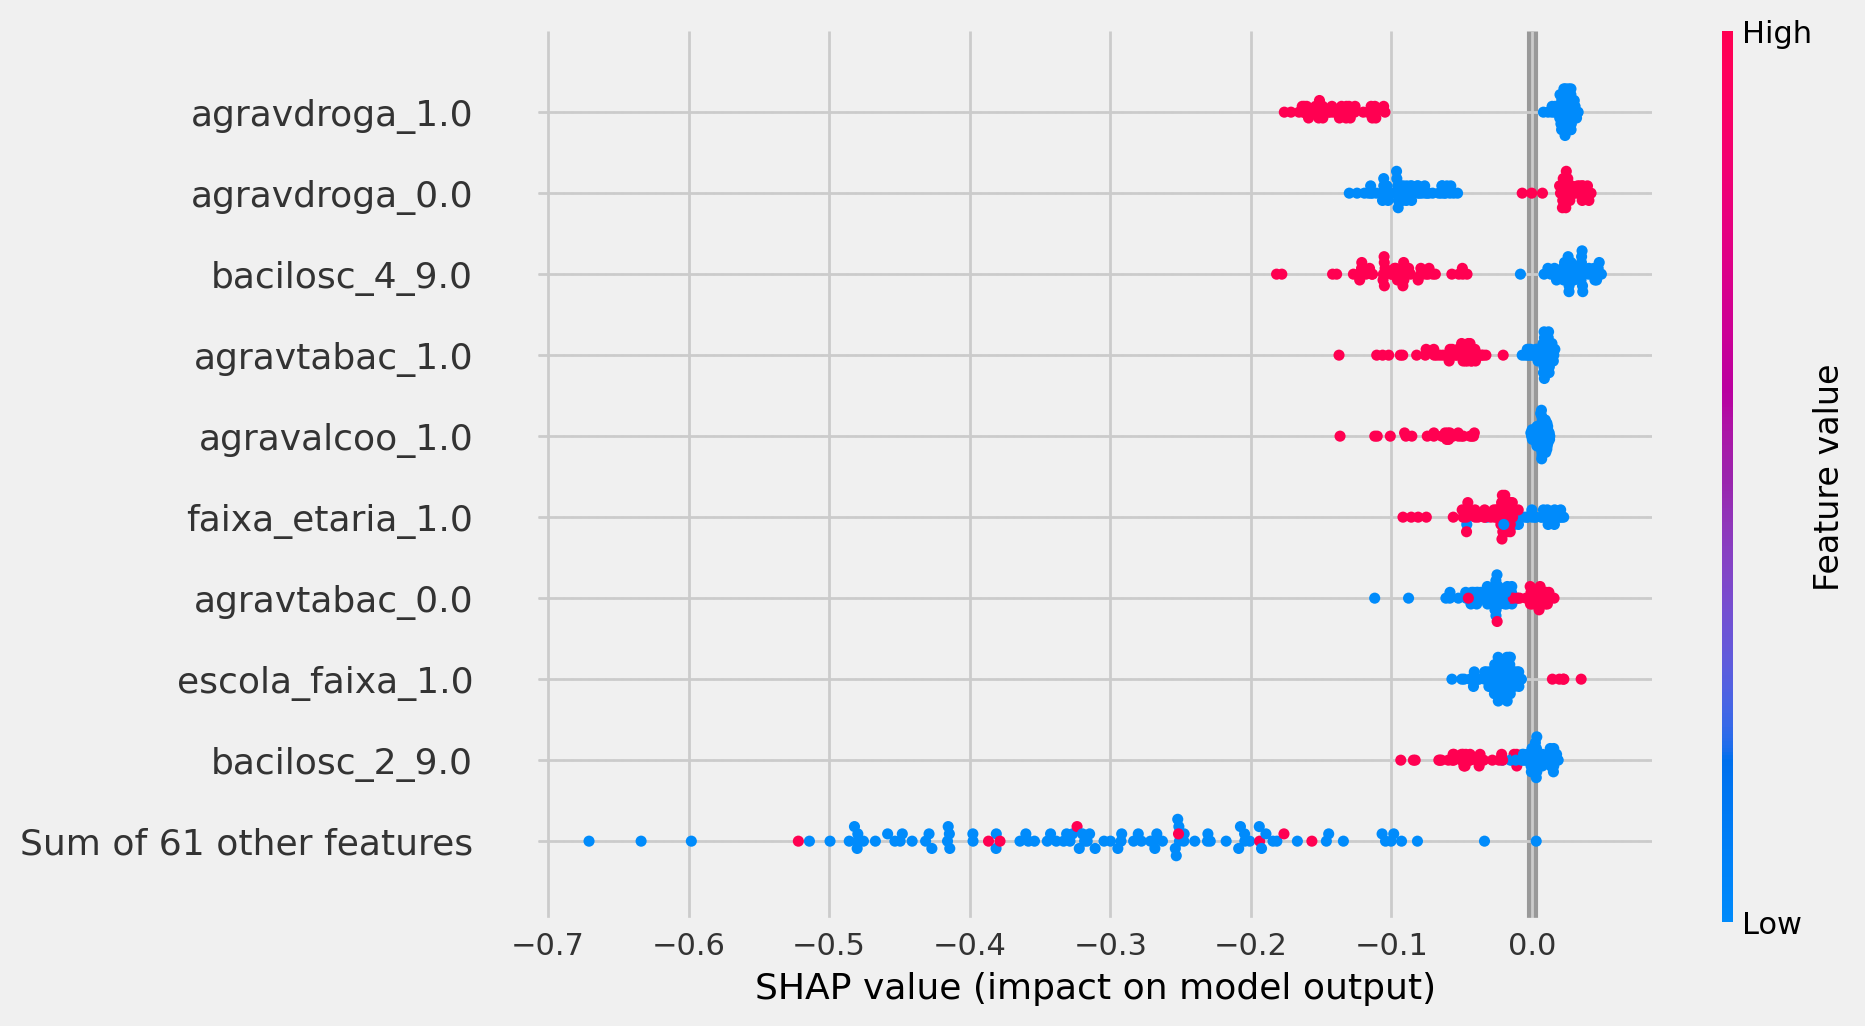

In [ ]:
import shap
import pandas as pd
import numpy as np

# =====================================================
# Seleciona um conjunto de fundo (background)
# =====================================================

background = shap.sample(X_train_tabpfn, 100, random_state=seed)

# =====================================================
# Cria o explicador SHAP
# =====================================================

explainer = shap.Explainer(
    tabpfn.predict_proba,
    background
)

# =====================================================
# Calcula os valores SHAP
# (use poucas amostras inicialmente para acelerar)
# =====================================================

X_explain = X_train_tabpfn.iloc[:100]

shap_values = explainer(X_explain)

# =====================================================
# Gráfico resumo
# =====================================================

shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
importance = pd.DataFrame({
    "Variavel": X_explain.columns,
    "SHAP": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
})

importance = (
    importance
    .sort_values("SHAP", ascending=False)
    .head(20)
)

print(importance)

            Variavel      SHAP
51    agravdroga_1.0  0.078195
50    agravdroga_0.0  0.064267
37    bacilosc_4_9.0  0.063927
54    agravtabac_1.0  0.033306
15    agravalcoo_1.0  0.025230
66  faixa_etaria_1.0  0.023860
53    agravtabac_0.0  0.023246
58  escola_faixa_1.0  0.022708
33    bacilosc_2_9.0  0.021233
35    bacilosc_4_2.0  0.018710
4        cs_raca_1.0  0.017950
57  escola_faixa_0.0  0.017211
25    bacilosc_e_3.0  0.015407
14    agravalcoo_0.0  0.013764
2        cs_sexo_1.0  0.012555
7        cs_raca_4.0  0.012496
1        cs_sexo_0.0  0.011776
32    bacilosc_2_3.0  0.011693
36    bacilosc_4_3.0  0.011683
31    bacilosc_2_2.0  0.011344


In [ ]:
top20shap = importance.head(20)

print("\nTop 20 variáveis mais importantes:")
print(top20shap)


Top 20 variáveis mais importantes:
            Variavel      SHAP
51    agravdroga_1.0  0.078195
50    agravdroga_0.0  0.064267
37    bacilosc_4_9.0  0.063927
54    agravtabac_1.0  0.033306
15    agravalcoo_1.0  0.025230
66  faixa_etaria_1.0  0.023860
53    agravtabac_0.0  0.023246
58  escola_faixa_1.0  0.022708
33    bacilosc_2_9.0  0.021233
35    bacilosc_4_2.0  0.018710
4        cs_raca_1.0  0.017950
57  escola_faixa_0.0  0.017211
25    bacilosc_e_3.0  0.015407
14    agravalcoo_0.0  0.013764
2        cs_sexo_1.0  0.012555
7        cs_raca_4.0  0.012496
1        cs_sexo_0.0  0.011776
32    bacilosc_2_3.0  0.011693
36    bacilosc_4_3.0  0.011683
31    bacilosc_2_2.0  0.011344


####Rodando modelo reduzido

In [ ]:
from tabpfn_client import TabPFNClassifier
from sklearn.metrics import roc_auc_score

# Seleciona as 20 variáveis mais importantes
top20_shap = importance.head(20)['Variavel'].tolist()

print("Top 20 variáveis:")
print(top20_shap)

# Conjunto de treino reduzido
X_train_top20shap = X_train_tabpfn[top20_shap]

# Novo modelo
tabpfn_top20_shap = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

# Ajuste
tabpfn_top20_shap.fit(X_train_top20shap, y_train_tabpfn)

# Probabilidades previstas no treino
y_proba_train_shap = tabpfn_top20_shap.predict_proba(X_train_top20shap)[:, 1]

Top 20 variáveis:
['agravdroga_1.0', 'agravdroga_0.0', 'bacilosc_4_9.0', 'agravtabac_1.0', 'agravalcoo_1.0', 'faixa_etaria_1.0', 'agravtabac_0.0', 'escola_faixa_1.0', 'bacilosc_2_9.0', 'bacilosc_4_2.0', 'cs_raca_1.0', 'escola_faixa_0.0', 'bacilosc_e_3.0', 'agravalcoo_0.0', 'cs_sexo_1.0', 'cs_raca_4.0', 'cs_sexo_0.0', 'bacilosc_2_3.0', 'bacilosc_4_3.0', 'bacilosc_2_2.0']
00:02 Fitting... Done!
00:02 Predicting... Done!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

scores = cross_val_score(
    tabpfn_novo,
    X_train_top20shap,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

00:02 Fitting... Done!
00:01 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:02 Fitting... Done!
00:03 Predicting... Done!
00:04 Fitting... Done!
00:03 Predicting... Done!
[0.85645714 0.75485322 0.86375473 0.75023674 0.88392857]
0.8218460822510822


In [ ]:
auc_cv_novo_tabpfn = scores.mean()

In [ ]:
auc_cv_novo_tabpfn

np.float64(0.8218460822510822)

In [ ]:
# Bases com variáveis selecionadas
X_train_novo = X_train[top20_shap].copy()
X_test_novo = X_test[top20_shap].copy()

# Unificando com a variável alvo
df_train_novo = pd.concat([X_train_novo, y_train], axis=1)
df_test_novo = pd.concat([X_test_novo, y_test], axis=1)

####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_tabpfn3boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_tabpfn3boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_tabpfn3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_teste_tabpfn3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

### Retreino do Modelo

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train_novo, y_train)
predictions = clf.predict(X_test_novo)

00:03 Fitting... Done!
00:03 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn_novo=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_novo = df_train.copy()
df_train_novo = (
    df_train_novo
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_novo)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_novo_tabpfn = df_train_novo.drop(columns = "cura")
y_train_tabpfn = df_train_novo.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_novo_tabpfn, y_train_tabpfn)


00:00 Fitting... \

00:02 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '766bf9f6073c4f0db02cdc08a6e86edb'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_novo_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_novo_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_novo_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
00:00 Fitting... \

...

00:02 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:01 Predicting... Done!
AUC CV TabPFN: 0.8218
Desvio padrão: 0.0573
AUC por fold: [0.85645714 0.75485322 0.86375473 0.75023674 0.88392857]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_novo_tabpfn = tabpfn.predict_proba(X_test_novo)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_novo_tabpfn = (y_prob_novo_tabpfn >= threshold).astype(int)

# Métricas
auc_novo_tabpfn = roc_auc_score(y_test, y_prob_novo_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn_novo - ROC AUC: {auc_novo_tabpfn:.4f}')


00:03 Predicting... Done!
tabpfn_novo - ROC AUC: 0.7399


In [ ]:
tabpfn_novo.fit(X_train_novo_tabpfn, y_train_tabpfn)

y_prob_novo_tabpfn = tabpfn_novo.predict_proba(X_test_novo)[:, 1]
auc_novo_tabpfn = roc_auc_score(y_test, y_prob_novo_tabpfn)

print(f"AUC CV (treino): {auc_cv_novo_tabpfn:.4f}")
print(f"AUC Teste      : {auc_novo_tabpfn:.4f}")

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV (treino): 0.8218
AUC Teste      : 0.7399


####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn_novo.pkl"

joblib.dump(tabpfn_novo, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn_novo.pkl


In [ ]:
joblib.dump(
    {
        "model_tabpfn_novo": tabpfn_novo,
        "auc_cv_tabpfn_novo": auc_cv_novo_tabpfn,
        "features": list(X_train_novo.columns)
    },
    caminho
)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn_novo.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn_novo = data["model_tabpfn_novo"]
auc_cv_tabpfn_novo = data["auc_cv_tabpfn_novo"]
features_tabpfn = data["features"]

####Comparacao modelo completo e boruta - tabela

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
import joblib
import pandas as pd

# Modelo completo
data_full = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl"
)

# Modelo Boruta/Top Features
data_novo = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn_novo.pkl"
)

auc_cv_tabpfn = data_full["auc_cv_tabpfn"]
auc_cv_tabpfn_novo = data_novo["auc_cv_tabpfn_novo"]

comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Boruta"],
    "AUC-CV": [auc_cv_tabpfn, auc_cv_tabpfn_novo]
})

print(comparacao)

if auc_cv_tabpfn > auc_cv_tabpfn_novo:
    print(f"\n🏆 Melhor modelo: Base Completa (AUC-CV = {auc_cv_tabpfn:.4f})")
elif auc_cv_tabpfn_novo > auc_cv_tabpfn:
    print(f"\n🏆 Melhor modelo: Boruta (AUC-CV = {auc_cv_tabpfn_novo:.4f})")
else:
    print("\n🤝 Os dois modelos possuem o mesmo AUC-CV.")

          Modelo    AUC-CV
0  Base Completa  0.817426
1         Boruta  0.821846

🏆 Melhor modelo: Boruta (AUC-CV = 0.8218)


# Comparando todos os modelos

In [ ]:
!pip install tabpfn-client
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score
from tabpfn_client import TabPFNClassifier # Added import for TabPFNClassifier

rf = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf.pkl")
xgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb.pkl")
lgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb.pkl")
cat = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat.pkl")
tabpfn = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn.pkl")
rf_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_rf_novo.pkl")
lgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_lgb_novo.pkl")
xgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_xgb_novo.pkl")
cat_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat_novo.pkl")
tabpfn_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_tabpfn_novo.pkl")

In [ ]:
# ===============================
# SEEDS DOS MODELOS
# ===============================

modelos = {
    "RandomForest": rf['model_rf'],
    "LGBM": lgb['model_lgb'],
    "XGBoost": xgb['model_xgb'],
    "CatBoost": cat['model_cat'],
    "TabPFN": tabpfn['model_tabpfn'],
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo'],
}

for nome, modelo in modelos.items():
    try:
        params = modelo.get_params()

        seed = (
            params.get('random_state')
            or params.get('seed')
            or params.get('random_seed')
        )

        print(f"{nome}: {seed}")

    except Exception as e:
        print(f"{nome}: não foi possível obter a seed ({e})")

RandomForest: 42
LGBM: 42
XGBoost: 42
CatBoost: 42
TabPFN: 42
RandomForest_novo: 42
LGBM_novo: 42
XGBoost_novo: 42
CatBoost_novo: 42
TabPFN_novo: 42


In [ ]:
# ============================================================
# CONTAGEM REAL DE VARIÁVEIS BORUTA E AUDITORIA DOS MODELOS
# ============================================================

import pandas as pd

TARGET = "cura"

# ------------------------
# Bases pós-Boruta
# ------------------------

paths_boruta = {
    "RandomForest_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_rf3boruta_rj_2015_2025.csv",

    "LGBM_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_lgb3boruta_rj_2015_2025.csv",

    "XGBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_xgb3boruta_rj_2015_2025.csv",

    "CatBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_cat3boruta_rj_2015_2025.csv",

    "TabPFN_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_tabpfn3boruta_rj_2015_2025.csv"
}

# ------------------------
# Modelos novos
# ------------------------

modelos_novos = {
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo']
}

audit_boruta = {}

for nome, caminho in paths_boruta.items():

    df_boruta = pd.read_csv(caminho)

    # Remove desfecho
    features_boruta = [c for c in df_boruta.columns if c != TARGET]

    n_features_boruta = len(features_boruta)

    modelo = modelos_novos[nome]

    # Recupera features efetivamente usadas pelo modelo
    try:

        if hasattr(modelo, "feature_names_in_"):
            features_modelo = list(modelo.feature_names_in_)

        elif hasattr(modelo, "feature_names_"):
            features_modelo = list(modelo.feature_names_)

        else:
            features_modelo = []

        n_features_modelo = len(features_modelo)

        faltantes = sorted(
            list(set(features_boruta) - set(features_modelo))
        )

        extras = sorted(
            list(set(features_modelo) - set(features_boruta))
        )

        status = (
            "OK"
            if len(faltantes) == 0 and len(extras) == 0
            else "DIVERGENTE"
        )

    except Exception as e:

        n_features_modelo = None
        faltantes = []
        extras = []
        status = f"Erro: {e}"

    audit_boruta[nome] = {
        "N_Boruta": n_features_boruta,
        "N_Modelo": n_features_modelo,
        "Status": status,
        "Faltantes": faltantes,
        "Extras": extras
    }

# ------------------------
# Mostrar auditoria
# ------------------------

print("\n" + "="*60)
print("AUDITORIA BORUTA × MODELO")
print("="*60)

for nome, info in audit_boruta.items():

    print(f"\n{nome}")
    print(f"Variáveis Boruta : {info['N_Boruta']}")
    print(f"Variáveis Modelo : {info['N_Modelo']}")
    print(f"Status           : {info['Status']}")

    if len(info['Faltantes']) > 0:
        print(f"\nFaltantes ({len(info['Faltantes'])}):")
        print(info['Faltantes'])

    if len(info['Extras']) > 0:
        print(f"\nExtras ({len(info['Extras'])}):")
        print(info['Extras'])


AUDITORIA BORUTA × MODELO

RandomForest_novo
Variáveis Boruta : 17
Variáveis Modelo : 17
Status           : OK

LGBM_novo
Variáveis Boruta : 14
Variáveis Modelo : 14
Status           : OK

XGBoost_novo
Variáveis Boruta : 26
Variáveis Modelo : 26
Status           : OK

CatBoost_novo
Variáveis Boruta : 19
Variáveis Modelo : 19
Status           : OK

TabPFN_novo
Variáveis Boruta : 20
Variáveis Modelo : 0
Status           : DIVERGENTE

Faltantes (20):
['agravalcoo_0.0', 'agravalcoo_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'bacilosc_4_2.0', 'bacilosc_4_3.0', 'bacilosc_4_9.0', 'bacilosc_e_3.0', 'cs_raca_1.0', 'cs_raca_4.0', 'cs_sexo_0.0', 'cs_sexo_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'faixa_etaria_1.0']


In [ ]:
resultados_cv = [

    {
        "Modelo": "RandomForest",
        "AUC_CV": rf["auc_cv_rf"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "LGBM",
        "AUC_CV": lgb["auc_cv_lgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "XGBoost",
        "AUC_CV": xgb["auc_cv_xgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "CatBoost",
        "AUC_CV": cat["auc_cv_cat"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "TabPFN",
        "AUC_CV": tabpfn["auc_cv_tabpfn"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "RandomForest_novo",
        "AUC_CV": rf_novo["auc_cv_rf_novo"],
        "N_Features": audit_boruta["RandomForest_novo"]["N_Boruta"]
    },

    {
        "Modelo": "LGBM_novo",
        "AUC_CV": lgb_novo["auc_cv_lgb_novo"],
        "N_Features": audit_boruta["LGBM_novo"]["N_Boruta"]
    },

    {
        "Modelo": "XGBoost_novo",
        "AUC_CV": xgb_novo["auc_xgb_novo"],
        "N_Features": audit_boruta["XGBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "CatBoost_novo",
        "AUC_CV": cat_novo["auc_cv_cat_novo"],
        "N_Features": audit_boruta["CatBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "TabPFN_novo",
        "AUC_CV": tabpfn_novo["auc_cv_tabpfn_novo"],
        "N_Features": audit_boruta["TabPFN_novo"]["N_Boruta"]
    }
]

df_cv = (
    pd.DataFrame(resultados_cv)
      .sort_values("AUC_CV", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA")
print("=" * 60)
print(df_cv)




RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA
              Modelo    AUC_CV  N_Features
0        TabPFN_novo  0.821846          20
1             TabPFN  0.817426          58
2      CatBoost_novo  0.765512          19
3       XGBoost_novo  0.764130          26
4            XGBoost  0.763613          58
5           CatBoost  0.763368          58
6               LGBM  0.763230          58
7       RandomForest  0.757919          58
8          LGBM_novo  0.753800          14
9  RandomForest_novo  0.753716          17
